# GNEISS ARV/VEE/BVR red–green inversion series

This notebook produces a combined ARV/VEE/BVR inversion between `start` and `end` (inclusive), sampled every `step_seconds`. It calibrates 630.0 and 557.7 nm images independently for each site, maps both channels to a common 110 km geographic grid, and performs the red–green-only inversion with each site's GLOW table. Every grid cell is then assigned to the geographically nearest camera having a valid inversion, without feathering, and only the combined product is saved. The 427.8 and 844.6 nm channels remain inactive.

Lookup tables, magnetic mapping, and the common grid are evaluated once. The entire launch series uses a fixed Apex model epoch of 10:24 UTC, so every inversion shares exactly the same two-dimensional geographic grid.

## Imports

In [60]:
import datetime as dt
import functools
import glob
import json
import os
import re
import sys
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
import imageio.v3 as iio
import h5py
import numpy as np
import pymap3d as pm
import tifffile
from astropy.io import fits
from apexpy import Apex
from scipy.io import readsav
from scipy.interpolate import griddata
from scipy.ndimage import distance_transform_edt, label as connected_component_labels
from scipy.spatial import Delaunay
from skimage.restoration import cycle_spin, denoise_wavelet

project_root = Path.cwd().resolve()
local_src = str(project_root / 'src')
for import_path in (local_src,):
    if import_path not in sys.path:
        sys.path.insert(0, import_path)

from asispectralinversion.inversion import (
    calculate_E0_Q_v2_RGonly,
    calculate_Sig,
    load_lookup_tables,
    load_lookup_tables_directory,
)
from asispectralinversion.config import load_config
from asi_shared.calibration import (
    EXPOSURE_TIME_S_BY_COLOR,
    GREEN_RAYLEIGH_SECONDS_PER_COUNT,
    RED_RAYLEIGH_SECONDS_PER_COUNT,
)
from asi_shared.background import estimate_scalar_background, physical_offsky_mask
from asi_shared.starmaps import azel2geo

<!-- Window-quality scan implementation; executed in its section below. -->

In [61]:
window_quality_scan_source = r'''
quality_scan_start = parse_utc('09:50:00')
quality_scan_end = parse_utc('10:30:00')
quality_scan_step = dt.timedelta(seconds=60)
quality_invalid_fraction_threshold = 0.005
quality_largest_hole_area_threshold_km2 = 100.0
quality_worst_map_count = 3

quality_scan_times = []
scan_time = quality_scan_start
while scan_time <= quality_scan_end:
    quality_scan_times.append(scan_time)
    scan_time += quality_scan_step

def largest_component_pixels(mask):
    component_labels, component_count = connected_component_labels(
        np.asarray(mask, dtype=bool), structure=np.ones((3, 3), dtype=int)
    )
    if component_count == 0:
        return 0
    sizes = np.bincount(component_labels.ravel())
    return int(np.max(sizes[1:]))

quality_rows = []
worst_combined_holes = []
for scan_index, scan_time in enumerate(quality_scan_times):
    print(
        f'Quality scan [{scan_index + 1:02d}/{len(quality_scan_times):02d}] '
        f'{scan_time.time()} UTC', flush=True,
    )
    scan_result = process_time(scan_time, collect_diagnostics=True)
    row = {'time': scan_time, 'sites': {}}
    scan_diagnostics = [scan_result['sites'][site]['diagnostics'] for site in sites]
    coverage_stack = np.stack([
        diagnostics['red_finite'] & diagnostics['green_finite']
        for diagnostics in scan_diagnostics
    ])
    ownership_distances = np.stack([
        np.where(coverage_stack[index], site_distance_km[site], np.inf)
        for index, site in enumerate(sites)
    ])
    ownership_index = np.argmin(ownership_distances, axis=0)
    potential_coverage = np.any(coverage_stack, axis=0)
    fixed_combined_valid = np.zeros(decgridlat.shape, dtype=bool)
    for site_index, site in enumerate(sites):
        diagnostics = scan_diagnostics[site_index]
        owned = potential_coverage & (ownership_index == site_index)
        valid = scan_result['sites'][site]['valid']
        fixed_combined_valid[owned] = valid[owned]
        denominator = np.count_nonzero(owned)
        site_holes = owned & ~valid
        nonpositive = owned & ~diagnostics['positive_rg']
        ratio_failure = owned & diagnostics['positive_rg'] & ~diagnostics['ratio_in_lookup']
        q_failure = owned & diagnostics['ratio_in_lookup'] & ~diagnostics['q_finite']
        e0_failure = (
            owned & diagnostics['ratio_in_lookup'] & diagnostics['q_finite']
            & ~diagnostics['e0_finite']
        )
        row['sites'][site] = {
            'potential_pixels': denominator,
            'invalid_fraction': np.count_nonzero(site_holes) / denominator if denominator else np.nan,
            'nonpositive_fraction': np.count_nonzero(nonpositive) / denominator if denominator else np.nan,
            'ratio_failure_fraction': np.count_nonzero(ratio_failure) / denominator if denominator else np.nan,
            'q_failure_fraction': np.count_nonzero(q_failure) / denominator if denominator else np.nan,
            'e0_failure_fraction': np.count_nonzero(e0_failure) / denominator if denominator else np.nan,
            'largest_hole_pixels': largest_component_pixels(site_holes),
        }
    combined_holes = potential_coverage & ~fixed_combined_valid
    combined_denominator = np.count_nonzero(potential_coverage)
    combined_hole_pixels = np.count_nonzero(combined_holes)
    largest_pixels = largest_component_pixels(combined_holes)
    row['combined_hole_fraction'] = (
        combined_hole_pixels / combined_denominator if combined_denominator else np.nan
    )
    row['combined_largest_hole_pixels'] = largest_pixels
    row['combined_largest_hole_area_km2'] = largest_pixels * target_grid_spacing_km**2
    quality_rows.append(row)
    worst_combined_holes.append((largest_pixels, scan_time, combined_holes.copy()))
    worst_combined_holes.sort(key=lambda item: item[0], reverse=True)
    del worst_combined_holes[quality_worst_map_count:]

scan_hours = np.array([
    (row['time'] - quality_scan_start).total_seconds() / 3600 for row in quality_rows
])
scan_time_labels = [row['time'].strftime('%H:%M') for row in quality_rows]
combined_fractions = np.array([row['combined_hole_fraction'] for row in quality_rows])
combined_areas = np.array([row['combined_largest_hole_area_km2'] for row in quality_rows])

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True, constrained_layout=True)
axes[0].plot(scan_hours, 100 * combined_fractions, marker='o', label='Combined')
axes[0].axhline(100 * quality_invalid_fraction_threshold, color='red', linestyle='--', label='Flag threshold')
axes[0].set_ylabel('Combined holes (%)')
axes[0].legend()
axes[1].plot(scan_hours, combined_areas, marker='o')
axes[1].axhline(quality_largest_hole_area_threshold_km2, color='red', linestyle='--')
axes[1].set_ylabel('Largest combined hole (km²)')
for site in sites:
    axes[2].plot(
        scan_hours,
        100 * np.array([row['sites'][site]['invalid_fraction'] for row in quality_rows]),
        marker='o', label=site,
    )
axes[2].axhline(100 * quality_invalid_fraction_threshold, color='red', linestyle='--')
axes[2].set_ylabel('Site holes (%)')
axes[2].set_xlabel('UTC')
axes[2].set_xticks(scan_hours[::5], scan_time_labels[::5])
axes[2].legend()
plt.show()

flagged_rows = [
    row for row in quality_rows
    if row['combined_hole_fraction'] > quality_invalid_fraction_threshold
    or row['combined_largest_hole_area_km2'] > quality_largest_hole_area_threshold_km2
]
print(f'Flagged combined times: {len(flagged_rows)} of {len(quality_rows)}')
for row in flagged_rows:
    print(
        row['time'].strftime('%H:%M:%S'),
        f"holes={100 * row['combined_hole_fraction']:.3f}%",
        f"largest={row['combined_largest_hole_area_km2']:.1f} km²",
    )

fig, axes = plt.subplots(
    1, len(worst_combined_holes),
    figsize=(6 * len(worst_combined_holes), 5), constrained_layout=True,
)
axes = np.atleast_1d(axes)
for axis, (largest_pixels, worst_time, hole_mask) in zip(axes, worst_combined_holes):
    axis.pcolormesh(
        decgridlon, decgridlat, np.where(hole_mask, 1.0, np.nan),
        shading='nearest', cmap='Reds', vmin=0, vmax=1,
    )
    axis.set_title(
        f"{worst_time.strftime('%H:%M:%S')} UTC\n"
        f'{largest_pixels * target_grid_spacing_km**2:.1f} km² largest hole'
    )
    axis.set_xlabel('Longitude')
    axis.set_ylabel('Latitude')
plt.show()
'''

## Configuration

`start` and `end` are UTC times on `date`. The sequence includes `end` when it lands exactly on the requested step. Start with a short interval while testing; a full launch interval can contain many inversions.

In [118]:
run_config = load_config(project_root=project_root)
date = run_config.date
start = run_config.start
end = run_config.end
step_seconds = run_config.step_seconds
apex_reference_time = run_config.apex_reference_time

station = 'VEE'
sites = ('ARV', 'VEE', 'BVR')
site_coordinates = {
    'ARV': {'latitude': 68.127, 'longitude': -145.533},
    'VEE': {'latitude': 67.013, 'longitude': -146.407},
    'BVR': {'latitude': 66.360, 'longitude': -147.400},
}
site_config = {
    site: {
        **site_coordinates[site],
        'calibration_r_s_per_count': {
            'red': RED_RAYLEIGH_SECONDS_PER_COUNT[site],
            'green': GREEN_RAYLEIGH_SECONDS_PER_COUNT[site],
        },
        'exposure_seconds': dict(EXPOSURE_TIME_S_BY_COLOR),
    }
    for site in sites
}
frames_to_coadd = 3
common_mapping_altitude_km = 110.0
target_grid_spacing_km = run_config.target_grid_spacing_km
decimation = run_config.decimation
diagnostic_time = run_config.diagnostic_time

enable_wavelet_denoising = True
wavelet_max_shifts = {'red': 3, 'green': 3, 'blue': 4, '8446': 3}
background_edge_buffer_px = 100

# Performance switches; these do not change wavelet_max_shifts.
use_precomputed_regridding = True
cache_tiff_frames = True
parallel_sites = True
tiff_frame_cache_size = 128

# Optional channels are retained for future diagnostics but do not affect the RG inversion.
save_blue_diagnostics = False
include_8446_diagnostics = False       # 844.6 nm: starmap and calibration do not yet exist

calculate_conductances = True
save_results = True
overwrite_output = True
output_file = run_config.paths.output_root / f'gneiss_rg_{date}_{start.replace(":", "")}_{end.replace(":", "")}_step{step_seconds:g}s.h5'

image_root = run_config.paths.image_root
starmap_root = run_config.paths.starmap_root
glow_root = run_config.paths.glow_root

def parse_utc(value):
    return dt.datetime.strptime(f'{date} {value}', '%Y%m%d %H:%M:%S')

start_datetime = parse_utc(start)
end_datetime = parse_utc(end)
if end_datetime < start_datetime:
    raise ValueError('end must not be earlier than start')
if step_seconds <= 0:
    raise ValueError('step_seconds must be positive')

target_times = []
current = start_datetime
while current <= end_datetime:
    target_times.append(current)
    current += dt.timedelta(seconds=step_seconds)

print(f'{len(target_times)} inversions from {target_times[0]} through {target_times[-1]} UTC')
print(f'Target global-grid spacing: {target_grid_spacing_km:g} km; decimation={decimation}')

41 inversions from 2026-02-10 09:50:00 through 2026-02-10 10:30:00 UTC
Target global-grid spacing: 2 km; decimation=1


## Load inversion lookup tables

In [63]:
def one_match(pattern):
    matches = sorted(glob.glob(str(pattern)))
    if len(matches) != 1:
        raise FileNotFoundError(f'Expected one match for {pattern}, found {len(matches)}')
    return matches[0]

def load_site_lookup(site):
    site_dir = glow_root / site
    def main_file(stem):
        normal = sorted(site_dir.glob(f'{stem}*.bin'))
        if normal:
            return str(normal[0])
        # Some existing GLOW runs concatenated the site directory name to
        # the filename instead of writing inside it.
        return one_match(glow_root / f'{site}{stem}*.bin')
    airglow_dir = site_dir / 'airglow'
    lookup = load_lookup_tables(
        main_file('I6300'), main_file('I5577'), main_file('I4278'),
        main_file('ped3d'), main_file('hall3d'), main_file('edens3d'),
        plot=False,
    )
    airglow = load_lookup_tables(
        one_match(airglow_dir / 'I6300*.bin'),
        one_match(airglow_dir / 'I5577*.bin'),
        one_match(airglow_dir / 'I4278*.bin'),
        one_match(airglow_dir / 'ped3d*.bin'),
        one_match(airglow_dir / 'hall3d*.bin'),
        one_match(airglow_dir / 'edens3d*.bin'),
        plot=False,
    )
    lookup['redbright_airglow'] = airglow['redmat']
    lookup['greenbright_airglow'] = airglow['greenmat']
    lookup['bluebright_airglow'] = airglow['bluemat']
    lookup['sigP_bg'] = airglow['sigPmat']
    lookup['sigH_bg'] = airglow['sigHmat']
    lookup['SigP_bg'] = airglow['SigPmat']
    lookup['SigH_bg'] = airglow['SigHmat']
    return lookup

lookup_by_site = {site: load_site_lookup(site) for site in sites}
for site, lookup in lookup_by_site.items():
    print(site, 'GLOW params:', lookup['Params'][:8])

ARV GLOW params: [2.60410e+04 3.74400e+04 6.81270e+01 2.14467e+02 1.38900e+02 1.42100e+02
 1.44200e+02 1.00000e+01]
VEE GLOW params: [2.60410e+04 3.74400e+04 6.70130e+01 2.13593e+02 1.38900e+02 1.42100e+02
 1.44200e+02 1.00000e+01]
BVR GLOW params: [2.6041e+04 3.7440e+04 6.6360e+01 2.1260e+02 1.3890e+02 1.4210e+02
 1.4420e+02 1.0000e+01]


## Camera geometry

The VEE azimuth/elevation starmaps are intersected with the assumed emission shells (180 km for 630.0 nm and 110 km for 557.7 nm). Apex then maps both channels to the common 110 km altitude.

In [64]:
vee_site_lat = 67.013
vee_site_lon = -146.407
emission_altitude_km = {630.0: 180.0, 844.6: 180.0, 557.7: 110.0, 427.8: 107.0}
starmap_files = {
    630.0: (
        starmap_root / 'red/6300/VEE/VEE_GASI_630_20260210_080000_asistarcalibration_full_Az.sav',
        starmap_root / 'red/6300/VEE/VEE_GASI_630_20260210_080000_asistarcalibration_full_El.sav',
    ),
    557.7: (
        starmap_root / 'green/VEE/GNEISS/VEE_GASI_20260210_050100_rot5_full_Az.sav',
        starmap_root / 'green/VEE/GNEISS/VEE_GASI_20260210_050100_rot5_full_El.sav',
    ),
    427.8: (
        starmap_root / 'blue/VEE/VEE_MOOSE_4278_20260210_050000_asistarcalibration_full_Az.sav',
        starmap_root / 'blue/VEE/VEE_MOOSE_4278_20260210_050000_asistarcalibration_full_El.sav',
    ),
    844.6: None,  # Add the 844.6 nm az/el paths here when they become available.
}

def read_idl_starmap(wavelength_nm, minimum_elevation_deg=15.0):
    paths = starmap_files[wavelength_nm]
    if paths is None:
        raise FileNotFoundError(f'No {wavelength_nm} nm az/el starmaps are configured')
    az_path, el_path = paths
    az_data = readsav(az_path, python_dict=True)
    el_data = readsav(el_path, python_dict=True)
    az = np.asarray(az_data[next(iter(az_data))], dtype=float)
    el = np.asarray(el_data[next(iter(el_data))], dtype=float)
    if az.shape != el.shape:
        raise ValueError(f'Az/el shape mismatch for {wavelength_nm} nm')
    invalid = ~np.isfinite(az) | ~np.isfinite(el) | (el < minimum_elevation_deg)
    az[invalid] = np.nan
    el[invalid] = np.nan
    return az, el

def azel_to_geographic(az, el, altitude_km):
    site_x, site_y, site_z = pm.geodetic2ecef(vee_site_lat, vee_site_lon, 0.0)
    east, north, up = pm.aer2enu(az, el, 1.0)
    vx, vy, vz = pm.enu2uvw(east, north, up, vee_site_lat, vee_site_lon)
    earth = pm.Ellipsoid.from_name('wgs84')
    a2 = (earth.semimajor_axis + altitude_km * 1000.0) ** 2
    c2 = (earth.semiminor_axis + altitude_km * 1000.0) ** 2
    qa = vx**2 / a2 + vy**2 / a2 + vz**2 / c2
    qb = site_x * vx / a2 + site_y * vy / a2 + site_z * vz / c2
    qc = site_x**2 / a2 + site_y**2 / a2 + site_z**2 / c2 - 1.0
    discriminant = qb**2 - qa * qc
    distance = np.where(discriminant >= 0, (np.sqrt(discriminant) - qb) / qa, np.nan)
    lat, lon, _ = pm.ecef2geodetic(site_x + distance * vx, site_y + distance * vy, site_z + distance * vz)
    invalid = ~np.isfinite(az) | ~np.isfinite(el)
    lat[invalid] = np.nan
    lon[invalid] = np.nan
    return lat, lon

apex = Apex(date=parse_utc(apex_reference_time))

def mapped_starmap(wavelength_nm):
    az, el = read_idl_starmap(wavelength_nm)
    source_altitude = emission_altitude_km[wavelength_nm]
    lat, lon = azel_to_geographic(az, el, source_altitude)
    valid = np.isfinite(lat) & np.isfinite(lon)
    mapped_lat = np.full(lat.shape, np.nan)
    mapped_lon = np.full(lon.shape, np.nan)
    mapped_lat[valid], mapped_lon[valid], _ = apex.map_to_height(
        lat[valid], lon[valid], source_altitude, common_mapping_altitude_km
    )
    return mapped_lat, mapped_lon

red_lat, red_lon = mapped_starmap(630.0)
green_lat, green_lon = mapped_starmap(557.7)
blue_lat, blue_lon = mapped_starmap(427.8)
print('Red starmap:', red_lat.shape, 'Green starmap:', green_lat.shape, 'Blue starmap:', blue_lat.shape)

# Load the ARV/VEE/BVR red and green camera geometry.
# Paths are explicit because the legacy asi_mapping loader does not include
# the red/6300 directory component for ARV and BVR.
site_starmap_files = {
    'ARV': {
        'red': (
            starmap_root / 'red/6300/ARV/ARV_GASI_630_20260209_Az.FIT',
            starmap_root / 'red/6300/ARV/ARV_GASI_630_20260209_El.FIT',
        ),
        'green': (
            starmap_root / 'green/ARV/ARV_GASI_20260209_063700_rot5_full_Az.sav',
            starmap_root / 'green/ARV/ARV_GASI_20260209_063700_rot5_full_El.sav',
        ),
    },
    'VEE': {
        'red': starmap_files[630.0],
        'green': starmap_files[557.7],
    },
    'BVR': {
        'red': (
            starmap_root / 'red/6300/BVR/BVR_GASI_630_20260210_051800_asistarcalibration_full_Az.sav',
            starmap_root / 'red/6300/BVR/BVR_GASI_630_20260210_051800_asistarcalibration_full_El.sav',
        ),
        'green': (
            starmap_root / 'green/BVR/BVR_20260210_090000_750_rot5_Az.sav',
            starmap_root / 'green/BVR/BVR_20260210_090000_750_rot5_El.sav',
        ),
    },
}

def read_starmap_array(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    if path.suffix.lower() in ('.fit', '.fits'):
        return np.asarray(fits.getdata(path), dtype=float)
    data = readsav(path, python_dict=True)
    return np.asarray(data[next(iter(data))], dtype=float)

def load_site_skymap(site, channel):
    az_path, el_path = site_starmap_files[site][channel]
    az = read_starmap_array(az_path)
    el = read_starmap_array(el_path)
    if az.shape != el.shape:
        raise ValueError(f'{site} {channel} az/el shape mismatch: {az.shape} vs {el.shape}')
    minimum_elevation_deg = 22.0 #if site == 'ARV' else 15.0
    mask = ~np.isfinite(az) | ~np.isfinite(el) | (el < minimum_elevation_deg)
    source_altitude = emission_altitude_km[630.0 if channel == 'red' else 557.7]
    latitude = site_config[site]['latitude']
    longitude = site_config[site]['longitude']
    mapped_lat, mapped_lon = azel2geo(latitude, longitude, az, el, alt=source_altitude)
    return {
        'site_lat': latitude, 'site_lon': longitude,
        'azmt': az, 'elev': el, 'mask': mask,
        'lat': mapped_lat, 'lon': mapped_lon,
        'map_alt_km': source_altitude,
    }

red_skymaps_by_site = {site: load_site_skymap(site, 'red') for site in sites}
green_skymaps_by_site = {site: load_site_skymap(site, 'green') for site in sites}

def map_site_coordinates_to_common(skymap, source_altitude_km):
    source_lat = np.asarray(skymap['lat'], dtype=float)
    source_lon = np.asarray(skymap['lon'], dtype=float)
    base_mask = np.asarray(skymap['mask'], dtype=bool)
    valid = np.isfinite(source_lat) & np.isfinite(source_lon) & ~base_mask
    mapped_lat = np.full(source_lat.shape, np.nan)
    mapped_lon = np.full(source_lon.shape, np.nan)
    mapped_lat[valid], mapped_lon[valid], _ = apex.map_to_height(
        source_lat[valid], source_lon[valid],
        source_altitude_km, common_mapping_altitude_km,
    )
    return mapped_lat, mapped_lon

mapped_coordinates_by_site = {}
native_masks_by_site = {}
for site in sites:
    mapped_coordinates_by_site[site] = {
        'red': map_site_coordinates_to_common(
            red_skymaps_by_site[site], emission_altitude_km[630.0]
        ),
        'green': map_site_coordinates_to_common(
            green_skymaps_by_site[site], emission_altitude_km[557.7]
        ),
    }
    native_masks_by_site[site] = {}
    for channel, skymaps in (
        ('red', red_skymaps_by_site), ('green', green_skymaps_by_site)
    ):
        base_mask = np.asarray(skymaps[site]['mask'], dtype=bool)
        native_masks_by_site[site][channel] = {
            'base': base_mask,
        }

for site in sites:
    print(
        site,
        'red/green shapes:',
        mapped_coordinates_by_site[site]['red'][0].shape,
        mapped_coordinates_by_site[site]['green'][0].shape,
        'valid native FOV pixels:',
        f"red={np.count_nonzero(~native_masks_by_site[site]['red']['base']):,}",
        f"green={np.count_nonzero(~native_masks_by_site[site]['green']['base']):,}",
    )

Red starmap: (750, 750) Green starmap: (750, 750) Blue starmap: (512, 512)
ARV red/green shapes: (750, 750) (750, 750) valid native FOV pixels: red=253,860 green=332,655
VEE red/green shapes: (750, 750) (750, 750) valid native FOV pixels: red=290,040 green=274,322
BVR red/green shapes: (750, 750) (750, 750) valid native FOV pixels: red=240,692 green=264,748


## Global multi-site grid

In [65]:
def coordinate_bounds(lat, lon):
    valid = np.isfinite(lat) & np.isfinite(lon)
    return np.nanmin(lat[valid]), np.nanmax(lat[valid]), np.nanmin(lon[valid]), np.nanmax(lon[valid])

# Union of every site's ordinary valid red and green field of view. Pairwise
# ownership masks are deliberately excluded; ownership is assigned after inversion.
retained_latitudes = []
retained_longitudes = []
for site in sites:
    for channel in ('red', 'green'):
        channel_lat, channel_lon = mapped_coordinates_by_site[site][channel]
        retained = (
            np.isfinite(channel_lat) & np.isfinite(channel_lon)
            & ~native_masks_by_site[site][channel]['base']
        )
        retained_latitudes.append(channel_lat[retained])
        retained_longitudes.append(channel_lon[retained])
all_latitudes = np.concatenate(retained_latitudes)
all_longitudes = np.concatenate(retained_longitudes)
lat_min, lat_max = np.min(all_latitudes), np.max(all_latitudes)
lon_min, lon_max = np.min(all_longitudes), np.max(all_longitudes)
mean_latitude = 0.5 * (lat_min + lat_max)
latitude_step = target_grid_spacing_km / 111.0
longitude_step = target_grid_spacing_km / (111.0 * np.cos(np.deg2rad(mean_latitude)))
grid_lat_axis = np.arange(lat_min, lat_max + 0.5 * latitude_step, latitude_step)
grid_lon_axis = np.arange(lon_min, lon_max + 0.5 * longitude_step, longitude_step)
gridlon, gridlat = np.meshgrid(grid_lon_axis, grid_lat_axis, indexing='xy')
decgridlat = gridlat[::decimation, ::decimation]
decgridlon = gridlon[::decimation, ::decimation]

def interpolation_geometry(lat, lon):
    valid = np.isfinite(lat) & np.isfinite(lon)
    points = np.column_stack((lon[valid], lat[valid]))
    targets = np.column_stack((gridlon.ravel(), gridlat.ravel()))
    return valid, points, targets

red_coord_valid, red_points, grid_targets = interpolation_geometry(red_lat, red_lon)
green_coord_valid, green_points, _ = interpolation_geometry(green_lat, green_lon)
blue_coord_valid, blue_points, _ = interpolation_geometry(blue_lat, blue_lon)
channel_starmaps_by_site = {}
for site in sites:
    channel_starmaps_by_site[site] = {}
    for channel in ('red', 'green'):
        channel_lat, channel_lon = mapped_coordinates_by_site[site][channel]
        coordinate_valid, points, _ = interpolation_geometry(channel_lat, channel_lon)
        channel_starmaps_by_site[site][channel] = (
            channel_lat, channel_lon, coordinate_valid, points
        )

def build_linear_regridder(points, targets):
    triangulation = Delaunay(points)
    simplex = triangulation.find_simplex(targets)
    inside = simplex >= 0
    vertices = np.zeros((targets.shape[0], 3), dtype=np.int32)
    weights = np.zeros((targets.shape[0], 3), dtype=np.float64)
    inside_simplex = simplex[inside]
    vertices[inside] = triangulation.simplices[inside_simplex]
    transform = triangulation.transform[inside_simplex]
    barycentric = np.einsum(
        'nij,nj->ni', transform[:, :2, :], targets[inside] - transform[:, 2, :]
    )
    weights[inside, :2] = barycentric
    weights[inside, 2] = 1.0 - barycentric.sum(axis=1)
    return {'inside': inside, 'vertices': vertices, 'weights': weights}

precomputed_regridders = {
    site: {
        channel: build_linear_regridder(
            channel_starmaps_by_site[site][channel][3], grid_targets
        )
        for channel in ('red', 'green')
    }
    for site in sites
}
print('Global union grid:', gridlat.shape, 'Inversion grid:', decgridlat.shape)
print(f'Grid spacing ≈ {target_grid_spacing_km:g} km')
print('Fixed Apex reference time:', parse_utc(apex_reference_time), 'UTC')

Global union grid: (496, 441) Inversion grid: (496, 441)
Grid spacing ≈ 2 km
Fixed Apex reference time: 2026-02-10 10:00:00 UTC


## Image-processing functions

For each target time, the code finds the TIFF stack covering that time and averages the three closest frames within it. Background and noise are estimated independently at every time because detector offsets can drift.

In [66]:
def discover_site_tiffs(site, channel):
    if channel == 'red':
        directories = [image_root / 'red' / '6300' / site]
        if site == 'VEE':
            directories.insert(0, image_root / 'red' / '6300' / 'VEE' / 'GNEISS')
    elif channel == 'green':
        directories = [image_root / 'green' / site]
        if site == 'VEE':
            directories.insert(0, image_root / 'green' / 'VEE' / 'GNEISS')
    else:
        raise ValueError(f'Unsupported channel: {channel}')
    paths = {
        str(path)
        for directory in directories
        for pattern in ('*.tif', '*.tiff')
        for path in directory.glob(pattern)
        if date in path.name
    }
    return sorted(paths)

channel_files = {
    site: {
        channel: discover_site_tiffs(site, channel)
        for channel in ('red', 'green')
    }
    for site in sites
}
channel_cadence_seconds = {'red': 0.9, 'green': 0.3}
for site in sites:
    for channel in ('red', 'green'):
        if not channel_files[site][channel]:
            raise FileNotFoundError(f'No {site} {channel} TIFF stacks found for {date}')
        print(f'{site} {channel}: {len(channel_files[site][channel])} TIFF stacks')

def timestamp_from_filename(path):
    match = re.search(r'_(\d{8})_(\d{6})\.tiff?$', Path(path).name, re.IGNORECASE)
    if not match:
        raise ValueError(f'Cannot parse TIFF timestamp from {path}')
    return dt.datetime.strptime(''.join(match.groups()), '%Y%m%d%H%M%S')

def stack_info(path, cadence_seconds):
    start_time = timestamp_from_filename(path)
    with tifffile.TiffFile(path) as tif:
        page_count = len(tif.pages)
    end_time = start_time + dt.timedelta(seconds=(page_count - 1) * cadence_seconds)
    return start_time, end_time, page_count

stack_catalog = {
    site: {
        channel: [
            (path, *stack_info(path, channel_cadence_seconds[channel]))
            for path in channel_files[site][channel]
        ]
        for channel in ('red', 'green')
    }
    for site in sites
}

@functools.lru_cache(maxsize=None)
def open_tiff_stack(path):
    return tifffile.TiffFile(path)

@functools.lru_cache(maxsize=tiff_frame_cache_size)
def read_tiff_frame_cached(path, index):
    return open_tiff_stack(path).pages[index].asarray().astype(float)

def read_tiff_frame(path, index):
    if cache_tiff_frames:
        return read_tiff_frame_cached(path, index)
    with tifffile.TiffFile(path) as tif:
        return tif.pages[index].asarray().astype(float)

def coadd_closest_frames(site, channel, target_time):
    cadence = channel_cadence_seconds[channel]
    candidates = []
    for path, stack_start, _stack_end, page_count in stack_catalog[site][channel]:
        # Only indices near the target can be among the globally closest frames.
        center = round((target_time - stack_start).total_seconds() / cadence)
        nearby = range(
            max(0, center - frames_to_coadd),
            min(page_count, center + frames_to_coadd + 1),
        )
        for index in nearby:
            frame_time = stack_start + dt.timedelta(seconds=index * cadence)
            candidates.append((abs(frame_time - target_time), frame_time, path, index))
    if len(candidates) < frames_to_coadd:
        raise ValueError(f'Only {len(candidates)} {site} {channel} frames are available near {target_time.isoformat()} UTC')
    selected = sorted(candidates, key=lambda item: (item[0], item[1]))[:frames_to_coadd]
    selected.sort(key=lambda item: item[1])

    images = [read_tiff_frame(path, index) for _offset, _time, path, index in selected]
    filenames = [Path(path).name for _offset, _time, path, _index in selected]
    indices = [index for _offset, _time, _path, index in selected]
    frame_times = [frame_time for _offset, frame_time, _path, _index in selected]
    return np.mean(images, axis=0), filenames, indices, frame_times

def estimate_background(image, elevation):
    mask = physical_offsky_mask(
        elevation, edge_buffer_px=background_edge_buffer_px
    )
    background, sigma, _values = estimate_scalar_background(image, mask)
    return background, sigma

def denoise_image(image, invalid_mask, background, sigma, max_shifts):
    if not enable_wavelet_denoising:
        output = image.astype(float).copy()
        output[invalid_mask] = np.nan
        return output
    filled = np.where(invalid_mask | ~np.isfinite(image), background, image)
    output = cycle_spin(
        filled, func=denoise_wavelet, max_shifts=max_shifts,
        func_kw={'sigma': sigma, 'method': 'BayesShrink', 'mode': 'soft', 'rescale_sigma': True},
        workers=1, channel_axis=None,
    )
    output[invalid_mask] = np.nan
    return output

def regrid_channel(image, lat, lon, coordinate_valid, precomputed=None):
    if use_precomputed_regridding and precomputed is not None:
        source_values = image[coordinate_valid]
        inside = precomputed['inside']
        vertices = precomputed['vertices'][inside]
        vertex_values = source_values[vertices]
        output = np.full(grid_targets.shape[0], np.nan)
        usable = np.all(np.isfinite(vertex_values), axis=1)
        inside_indices = np.flatnonzero(inside)
        output[inside_indices[usable]] = np.einsum(
            'ni,ni->n', vertex_values[usable], precomputed['weights'][inside][usable]
        )
        return output.reshape(gridlat.shape)
    valid = coordinate_valid & np.isfinite(image)
    # Rebuild points only if the image contains additional invalid pixels.
    use_points = np.column_stack((lon[valid], lat[valid]))
    values = image[valid]
    return griddata(use_points, values, grid_targets, method='linear').reshape(gridlat.shape)

def finite_percentile(image, percentile=99.5):
    values = np.asarray(image)[np.isfinite(image)]
    if values.size == 0:
        raise ValueError('Cannot calculate a percentile from an all-NaN image')
    return np.percentile(values, percentile)

print('Calibration factors (R s/count):')
for site in sites:
    print(f"  {site}: {site_config[site]['calibration_r_s_per_count']}")
print('Exposure times (s):', dict(EXPOSURE_TIME_S_BY_COLOR))

ARV red: 6 TIFF stacks
ARV green: 25 TIFF stacks
VEE red: 8 TIFF stacks
VEE green: 27 TIFF stacks
BVR red: 9 TIFF stacks
BVR green: 25 TIFF stacks
Calibration factors (R s/count):
  ARV: {'red': 165.0, 'green': 64.0}
  VEE: {'red': 113.0, 'green': 35.0}
  BVR: {'red': 128.0, 'green': 57.0}
Exposure times (s): {'green': 0.3, 'red': 0.9}


## Optional 427.8 and 844.6 nm channels

Neither optional channel participates in the red–green inversion or restricts its valid coverage. The 427.8 nm loader remains available for later experiments. The 844.6 nm channel is registered, but enabling it raises a readiness error until its own az/el starmap and radiometric calibration are supplied.

In [67]:
optional_channels = {
    427.8: {
        'role': 'uncalibrated diagnostic',
        'image_file': image_root / 'blue/VEE/SOK260210_101900_102848_16bit.tif',
        'stack_start': dt.datetime.fromisoformat('2026-02-10T10:19:00.756700'),
        'cadence_seconds': 0.90178,
        'calibration_r_s_per_count': None,
        'starmap_ready': starmap_files[427.8] is not None,
    },
    844.6: {
        'role': 'future alternative red channel',
        'image_file': image_root / 'red/8446/VEE/PLA260210_09595909_16bit.tif',
        'stack_start': dt.datetime.fromisoformat('2026-02-10T10:00:00.005000'),
        'cadence_seconds': 0.9020278195488721,
        'calibration_r_s_per_count': None,
        'starmap_ready': starmap_files[844.6] is not None,
    },
}

def coadd_fixed_stack(channel_config, target_time):
    path = channel_config['image_file']
    cadence = channel_config['cadence_seconds']
    stack_start = channel_config['stack_start']
    if not path.exists():
        raise FileNotFoundError(path)
    with tifffile.TiffFile(path) as tif:
        page_count = len(tif.pages)
        stack_end = stack_start + dt.timedelta(seconds=(page_count - 1) * cadence)
        # Permit a target within one cadence of an endpoint; otherwise
        # represent the unavailable optional channel with NaNs.
        tolerance = dt.timedelta(seconds=cadence)
        if target_time < stack_start - tolerance or target_time > stack_end + tolerance:
            return None
        center = round((target_time - stack_start).total_seconds() / cadence)
        candidates = range(max(0, center - frames_to_coadd), min(page_count, center + frames_to_coadd + 1))
        indices = sorted(candidates, key=lambda index: abs((stack_start + dt.timedelta(seconds=index * cadence)) - target_time))[:frames_to_coadd]
        indices.sort()
        images = [tif.pages[index].asarray().astype(float) for index in indices]
    return np.mean(images, axis=0)

if include_8446_diagnostics:
    missing = []
    if not optional_channels[844.6]['starmap_ready']:
        missing.append('az/el starmap')
    if optional_channels[844.6]['calibration_r_s_per_count'] is None:
        missing.append('radiometric calibration')
    if missing:
        raise RuntimeError('844.6 nm is registered but not ready: missing ' + ' and '.join(missing))

blue_geometry = (blue_lat, blue_lon, blue_coord_valid)
blue_darkframe = iio.imread(project_root / 'biasframes/blue_bias_processed.png').astype(float) / 10.0
blue_darkframe -= np.mean(blue_darkframe)

print('Optional channel status:')
for wavelength, config in optional_channels.items():
    print(f"  {wavelength} nm: {config['role']}; starmap={config['starmap_ready']}; calibrated={config['calibration_r_s_per_count'] is not None}")

Optional channel status:
  427.8 nm: uncalibrated diagnostic; starmap=True; calibrated=False
  844.6 nm: future alternative red channel; starmap=False; calibrated=False


## Multi-site processing and inversion functions

In [68]:
site_codes = {'ARV': 1, 'VEE': 2, 'BVR': 3}

def process_channel(site, channel, target_time):
    channel_lat, channel_lon, coordinate_valid, _points = channel_starmaps_by_site[site][channel]
    image, filenames, indices, frame_times = coadd_closest_frames(site, channel, target_time)
    if image.shape != channel_lat.shape:
        raise ValueError(f'{site} {channel} image/starmap shape mismatch: {image.shape} vs {channel_lat.shape}')
    native_skymap = (
        red_skymaps_by_site[site] if channel == 'red' else green_skymaps_by_site[site]
    )
    background, sigma = estimate_background(image, native_skymap['elev'])
    prepared = denoise_image(
        image, ~coordinate_valid, background, sigma, wavelet_max_shifts[channel]
    )
    regridded = regrid_channel(
        prepared, channel_lat, channel_lon, coordinate_valid,
        precomputed_regridders[site][channel],
    )
    calibration = site_config[site]['calibration_r_s_per_count'][channel]
    exposure = site_config[site]['exposure_seconds'][channel]
    rayleighs = (regridded - background) / exposure * calibration
    metadata = {
        'files': filenames, 'indices': indices, 'frame_times': frame_times,
        'background_counts': background, 'sigma_counts': sigma,
    }
    return rayleighs, metadata

def process_blue(target_time):
    image = coadd_fixed_stack(optional_channels[427.8], target_time)
    if image is None:
        raise ValueError(f'Blue TIFF stack does not cover {target_time.isoformat()} UTC')
    corrected = image - blue_darkframe
    blue_elevation = read_starmap_array(starmap_files[427.8][1])
    background, sigma = estimate_background(corrected, blue_elevation)
    prepared = denoise_image(
        corrected, ~blue_coord_valid, background, sigma, wavelet_max_shifts['blue']
    )
    return regrid_channel(prepared, blue_lat, blue_lon, blue_coord_valid)

def invert_site(site, target_time, collect_diagnostics=False):
    red, red_metadata = process_channel(site, 'red', target_time)
    green, green_metadata = process_channel(site, 'green', target_time)
    red = red[::decimation, ::decimation]
    green = green[::decimation, ::decimation]
    red_finite = np.isfinite(red)
    green_finite = np.isfinite(green)
    positive_rg = red_finite & green_finite & (red > 0) & (green > 0)
    lookup = lookup_by_site[site]
    red_input = np.where(positive_rg, red, np.nan)
    green_input = np.where(positive_rg, green, np.nan)
    q, e0 = calculate_E0_Q_v2_RGonly(
        red_input, green_input, None, lookup, minE0=150,
        checkagreement=False, generous=False, plot=False,
    )
    sigp, sigh = (calculate_Sig(
        q, e0, lookup_by_site[site], generous=False, plot=False
    ) if calculate_conductances else (None, None))
    diagnostics = None
    if collect_diagnostics:
        observed_ratio = np.full(red.shape, np.nan)
        observed_ratio[positive_rg] = red[positive_rg] / green[positive_rg]
        lookup_red = lookup['redmat'] - lookup['redbright_airglow'][0][0]
        lookup_green = lookup['greenmat'] - lookup['greenbright_airglow'][0][0]
        lookup_ratio = np.divide(
            lookup_red, lookup_green,
            out=np.full_like(lookup_red, np.nan, dtype=float),
            where=np.isfinite(lookup_green) & (lookup_green != 0),
        )
        ratio_min, ratio_max = np.nanmin(lookup_ratio), np.nanmax(lookup_ratio)
        ratio_in_lookup = positive_rg & (observed_ratio >= ratio_min) & (observed_ratio <= ratio_max)
        diagnostics = {
            'red_finite': red_finite, 'green_finite': green_finite,
            'positive_rg': positive_rg, 'ratio_in_lookup': ratio_in_lookup,
            'q_finite': np.isfinite(q), 'e0_finite': np.isfinite(e0),
            'sigp_finite': np.isfinite(sigp) if sigp is not None else None,
            'sigh_finite': np.isfinite(sigh) if sigh is not None else None,
            'observed_ratio': observed_ratio,
            'observed_red': red, 'observed_green': green,
            'lookup_ratio_bounds': (ratio_min, ratio_max),
        }
    return {
        'q': q, 'e0': e0, 'sigp': sigp, 'sigh': sigh,
        'valid': np.isfinite(q) & np.isfinite(e0),
        'red_metadata': red_metadata, 'green_metadata': green_metadata,
        'diagnostics': diagnostics,
    }

site_distance_km = {}
for site in sites:
    north = (decgridlat - site_config[site]['latitude']) * 111.0
    east = ((decgridlon - site_config[site]['longitude']) * 111.0
            * np.cos(np.deg2rad(decgridlat)))
    site_distance_km[site] = np.hypot(north, east)

def combine_site_products(site_products):
    valid_stack = np.stack([site_products[site]['valid'] for site in sites])
    ownership_count = np.sum(valid_stack, axis=0).astype(np.uint8)
    distances = np.stack([
        np.where(site_products[site]['valid'], site_distance_km[site], np.inf)
        for site in sites
    ])
    chosen_index = np.argmin(distances, axis=0)
    has_value = ownership_count > 0
    source_site = np.zeros(decgridlat.shape, dtype=np.uint8)
    q = np.full(decgridlat.shape, np.nan, dtype=float)
    e0 = np.full(decgridlat.shape, np.nan, dtype=float)
    sigp = np.full(decgridlat.shape, np.nan, dtype=float) if calculate_conductances else None
    sigh = np.full(decgridlat.shape, np.nan, dtype=float) if calculate_conductances else None
    for index, site in enumerate(sites):
        selected = has_value & (chosen_index == index)
        source_site[selected] = site_codes[site]
        q[selected] = site_products[site]['q'][selected]
        e0[selected] = site_products[site]['e0'][selected]
        if calculate_conductances:
            sigp[selected] = site_products[site]['sigp'][selected]
            sigh[selected] = site_products[site]['sigh'][selected]
    return {
        'q': q, 'e0': e0, 'sigp': sigp, 'sigh': sigh,
        'source_site': source_site, 'ownership_count': ownership_count,
    }

site_executor = ThreadPoolExecutor(max_workers=len(sites), thread_name_prefix='gneiss-site')

def process_time(target_time, collect_diagnostics=False):
    if parallel_sites:
        futures = {
            site: site_executor.submit(invert_site, site, target_time, collect_diagnostics)
            for site in sites
        }
        site_products = {site: futures[site].result() for site in sites}
    else:
        site_products = {
            site: invert_site(site, target_time, collect_diagnostics)
            for site in sites
        }
    combined = combine_site_products(site_products)
    return {'time': target_time, 'sites': site_products, 'combined': combined}

## Run one diagnostic multi-site inversion


ARV outcome counts:
  Neither red nor green mapped: 89,326
  Green missing: 77,151
  Valid inversion: 52,259

VEE outcome counts:
  Neither red nor green mapped: 95,356
  Green missing: 73,523
  Red or green <= 0: 9
  Ratio outside GLOW envelope: 118
  E0 has no/ambiguous solution: 15
  Valid inversion: 49,715

BVR outcome counts:
  Neither red nor green mapped: 98,589
  Green missing: 71,587
  Valid inversion: 48,560


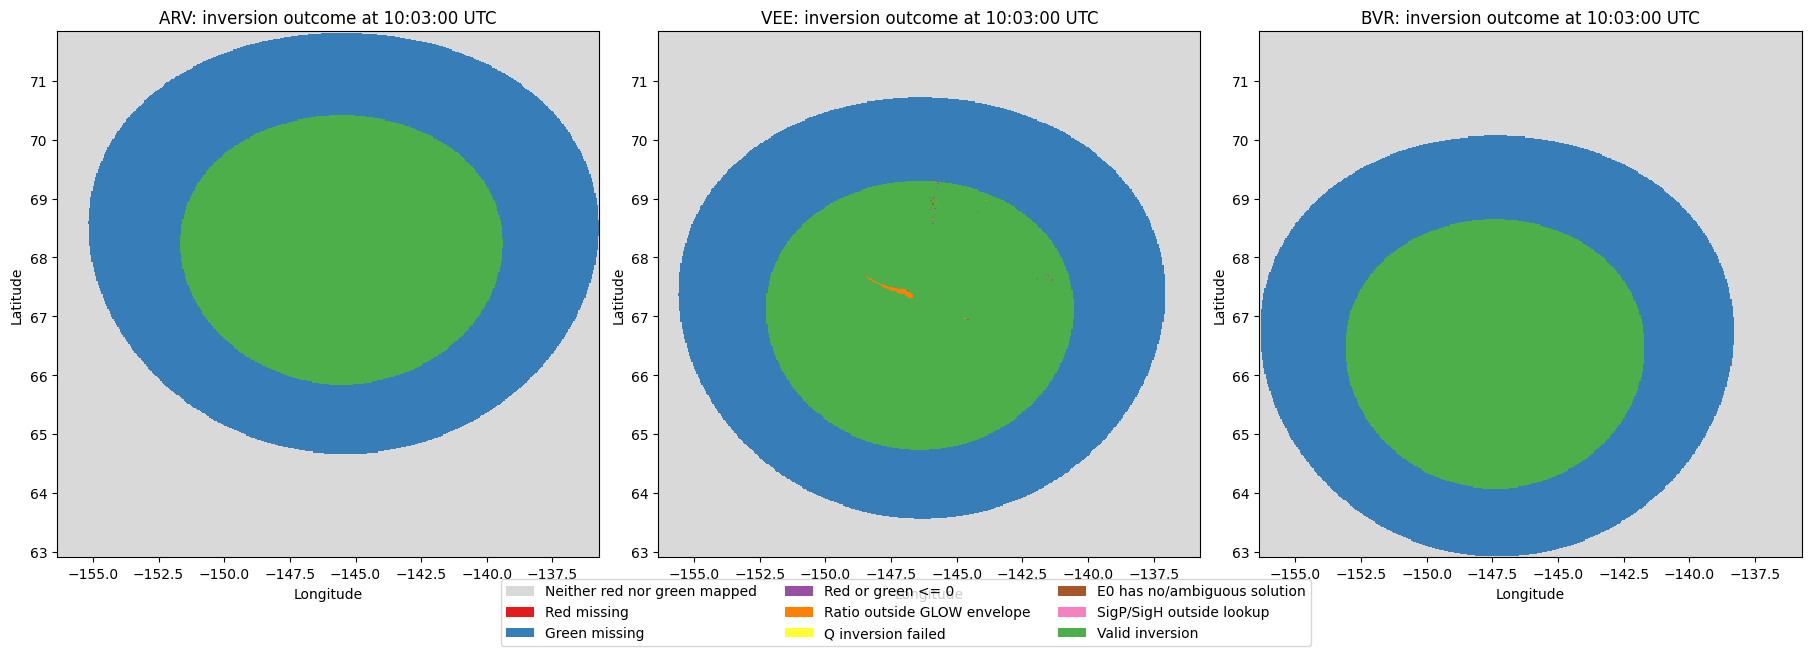


Fixed geometric ownership slices:
  ARV: 35,096 owned pixels
    Valid inversion: 35,096
  VEE: 13,432 owned pixels
    Ratio outside GLOW envelope: 114
    E0 has no/ambiguous solution: 3
    Valid inversion: 13,315
  BVR: 28,715 owned pixels
    Valid inversion: 28,715


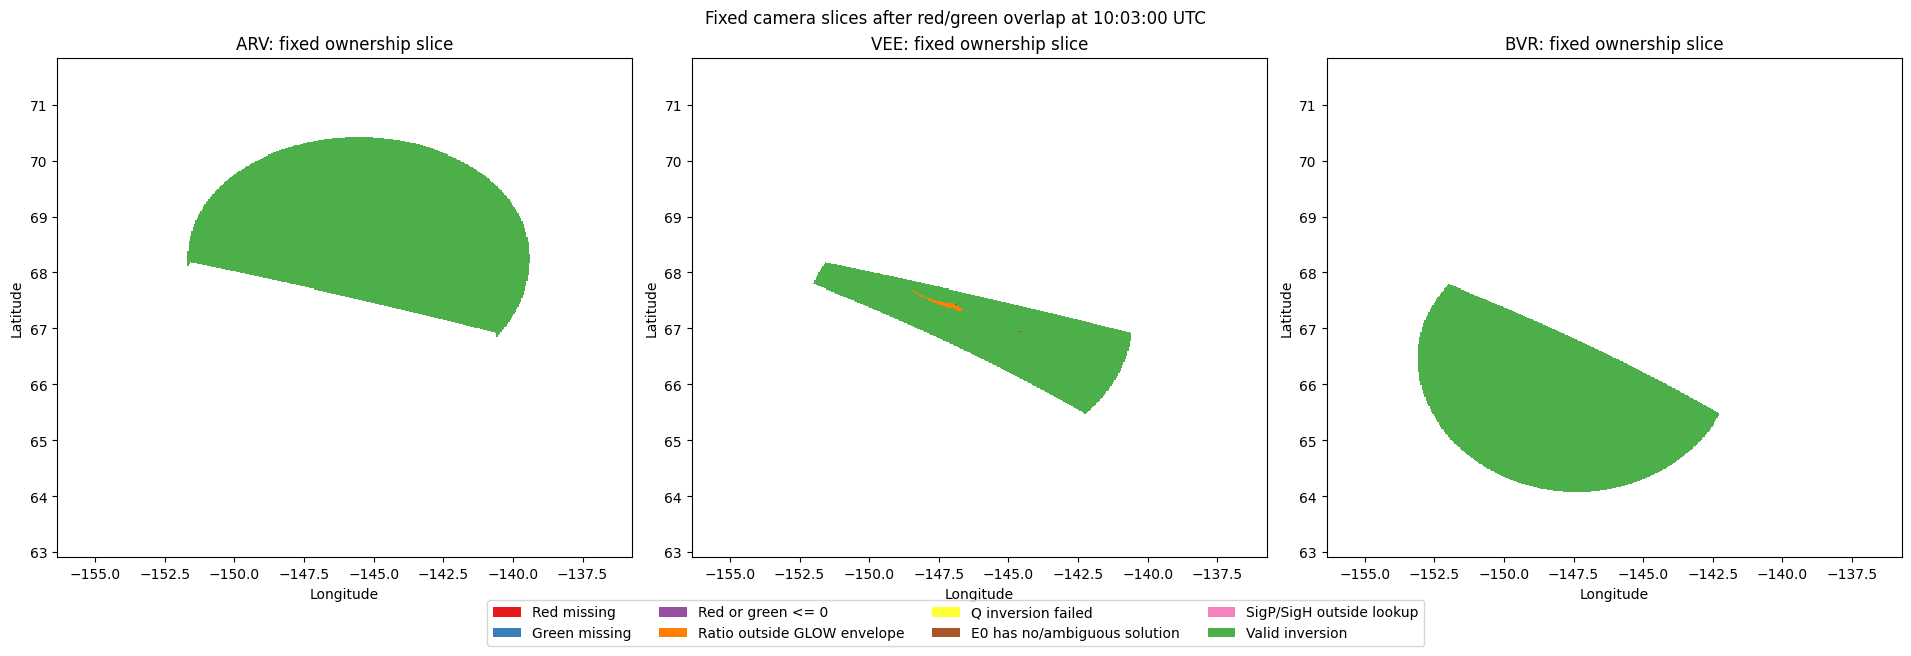

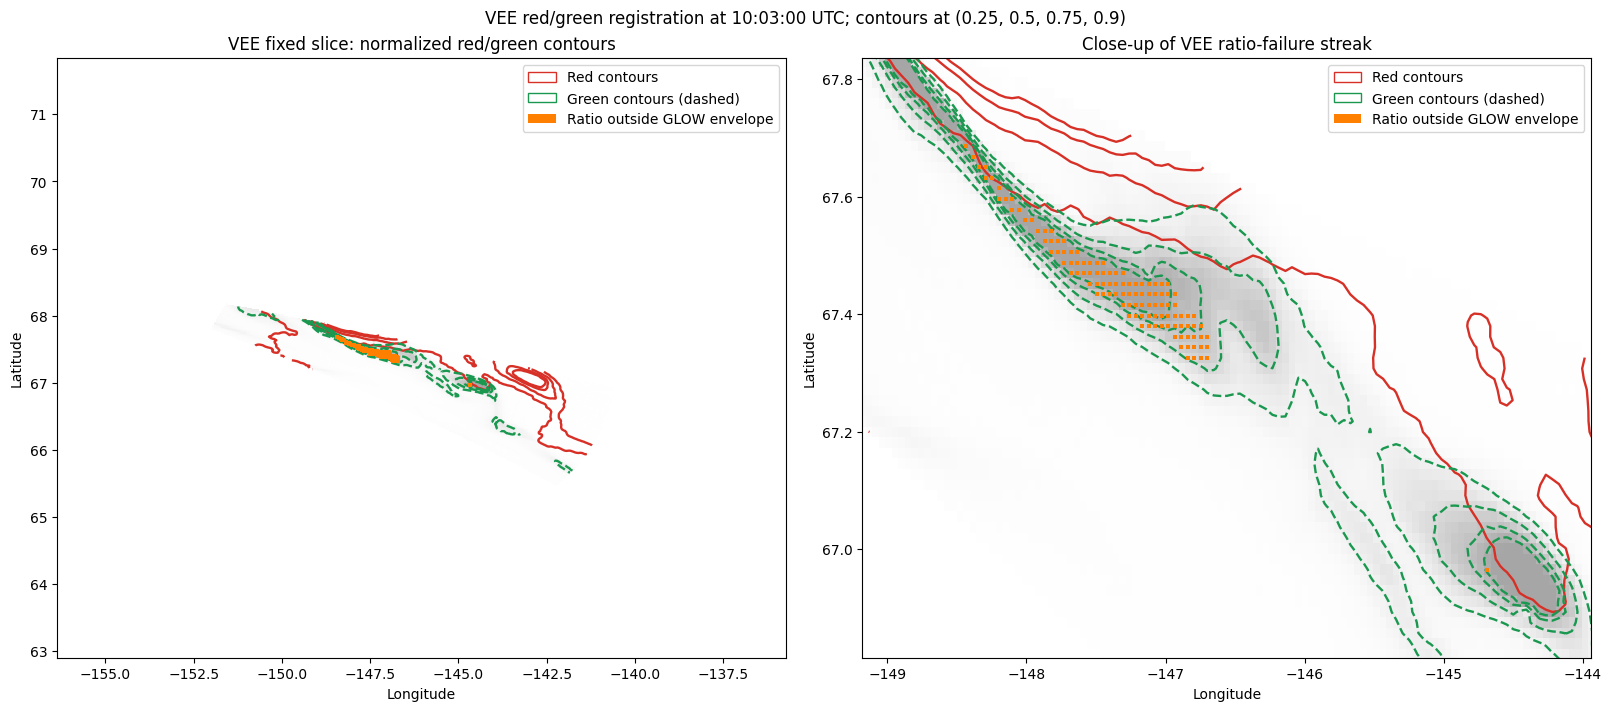

Vee registration scales (99th percentile): red=14771.8 R, green=399236.3 R; ratio-failure pixels=114


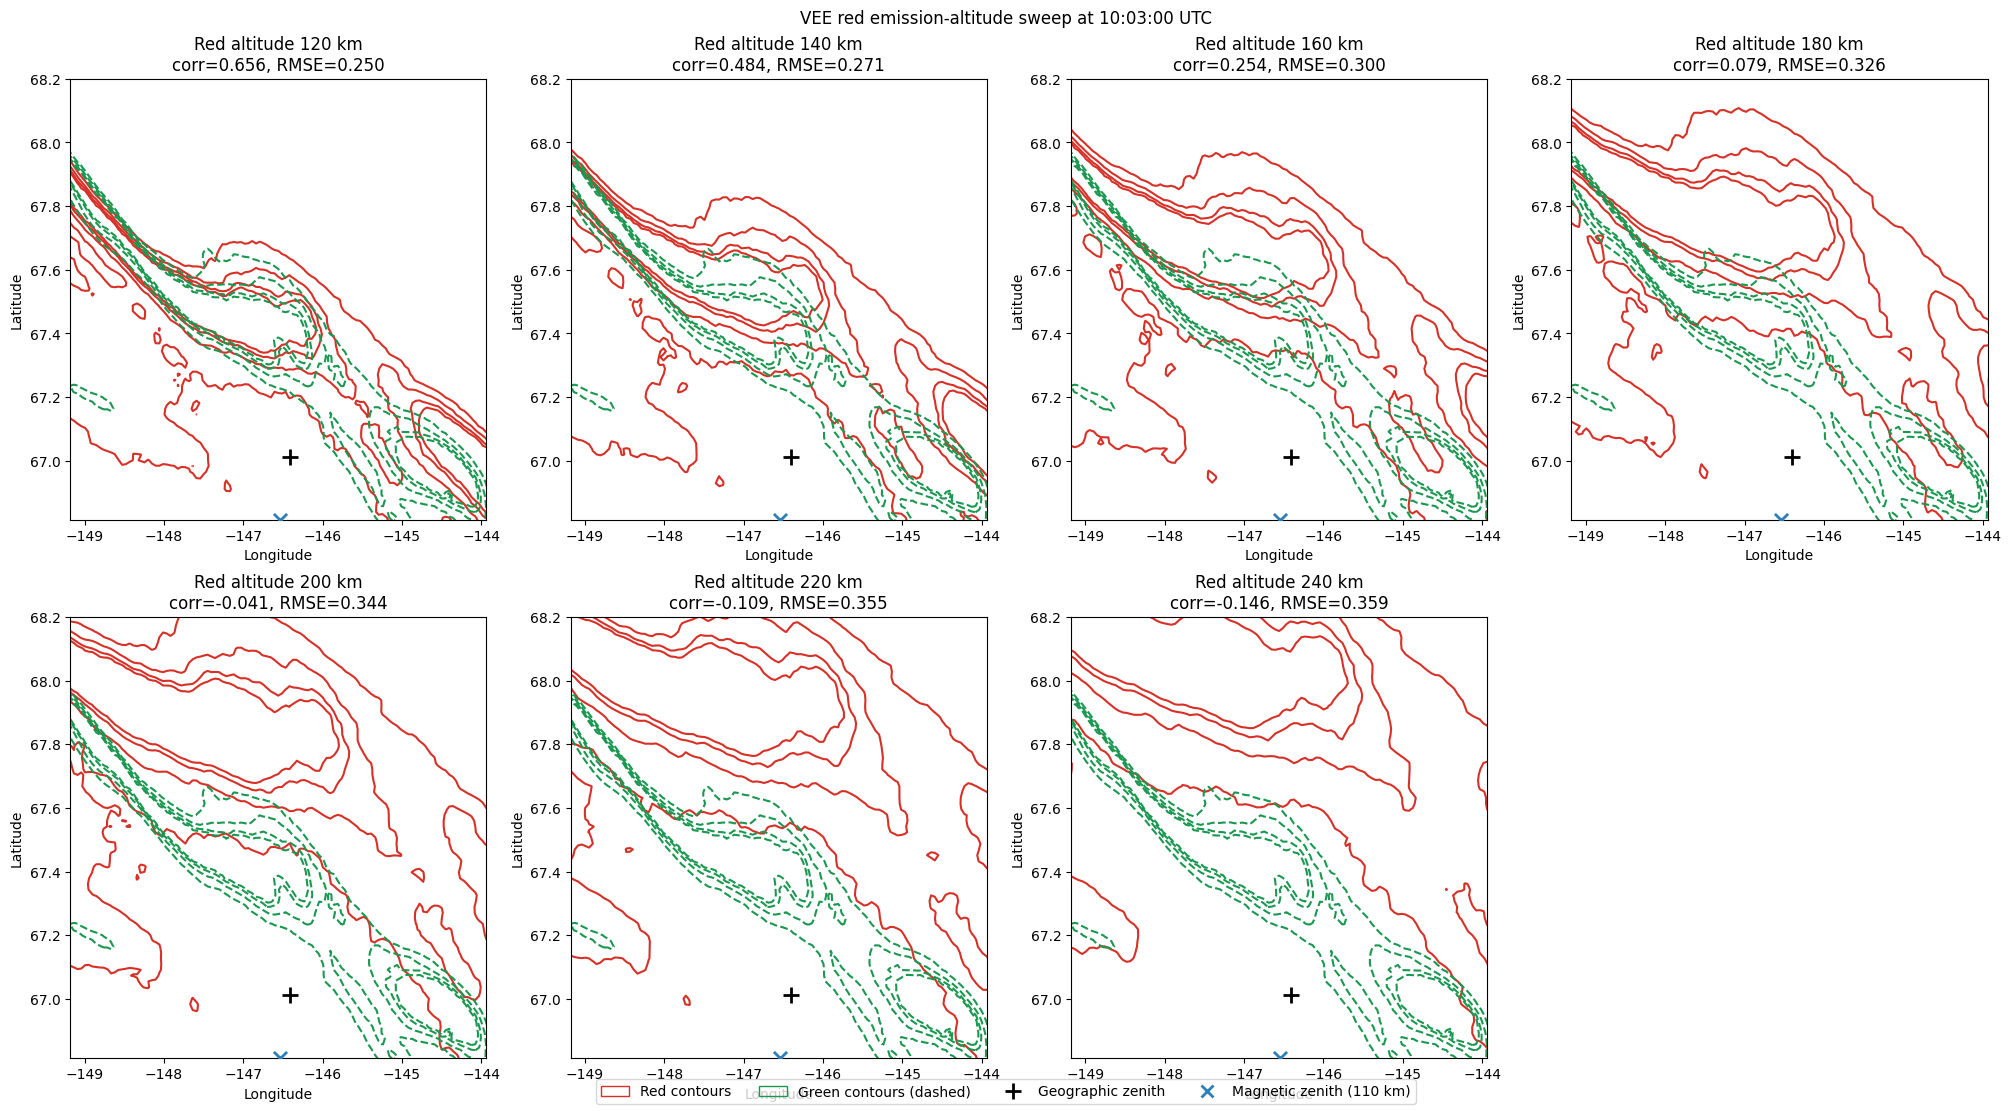

VEE red emission-altitude comparison:
  120 km: corr=0.656, RMSE=0.250
  140 km: corr=0.484, RMSE=0.271
  160 km: corr=0.254, RMSE=0.300
  180 km: corr=0.079, RMSE=0.326
  200 km: corr=-0.041, RMSE=0.344
  220 km: corr=-0.109, RMSE=0.355
  240 km: corr=-0.146, RMSE=0.359
Best correlation altitude: 120 km
Lowest RMSE altitude: 120 km

ARV GLOW ratio range: 0.007279 to 9.876
  Below minimum: 0; above maximum: 0
  Red frame times: 10:02:59.400000, 10:03:00.300000, 10:03:01.200000
  Green frame times: 10:02:59.600000, 10:02:59.900000, 10:03:00.200000

VEE GLOW ratio range: 0.007294 to 9.89
  Below minimum: 115; above maximum: 3
  Red frame times: 10:02:59.100000, 10:03:00, 10:03:00.900000
  Green frame times: 10:02:59.600000, 10:02:59.900000, 10:03:00.200000

BVR GLOW ratio range: 0.007309 to 9.9
  Below minimum: 0; above maximum: 0
  Red frame times: 10:02:58.800000, 10:02:59.700000, 10:03:00.600000
  Green frame times: 10:02:59.700000, 10:03:00, 10:03:00.300000
ARV: no ratios below the G

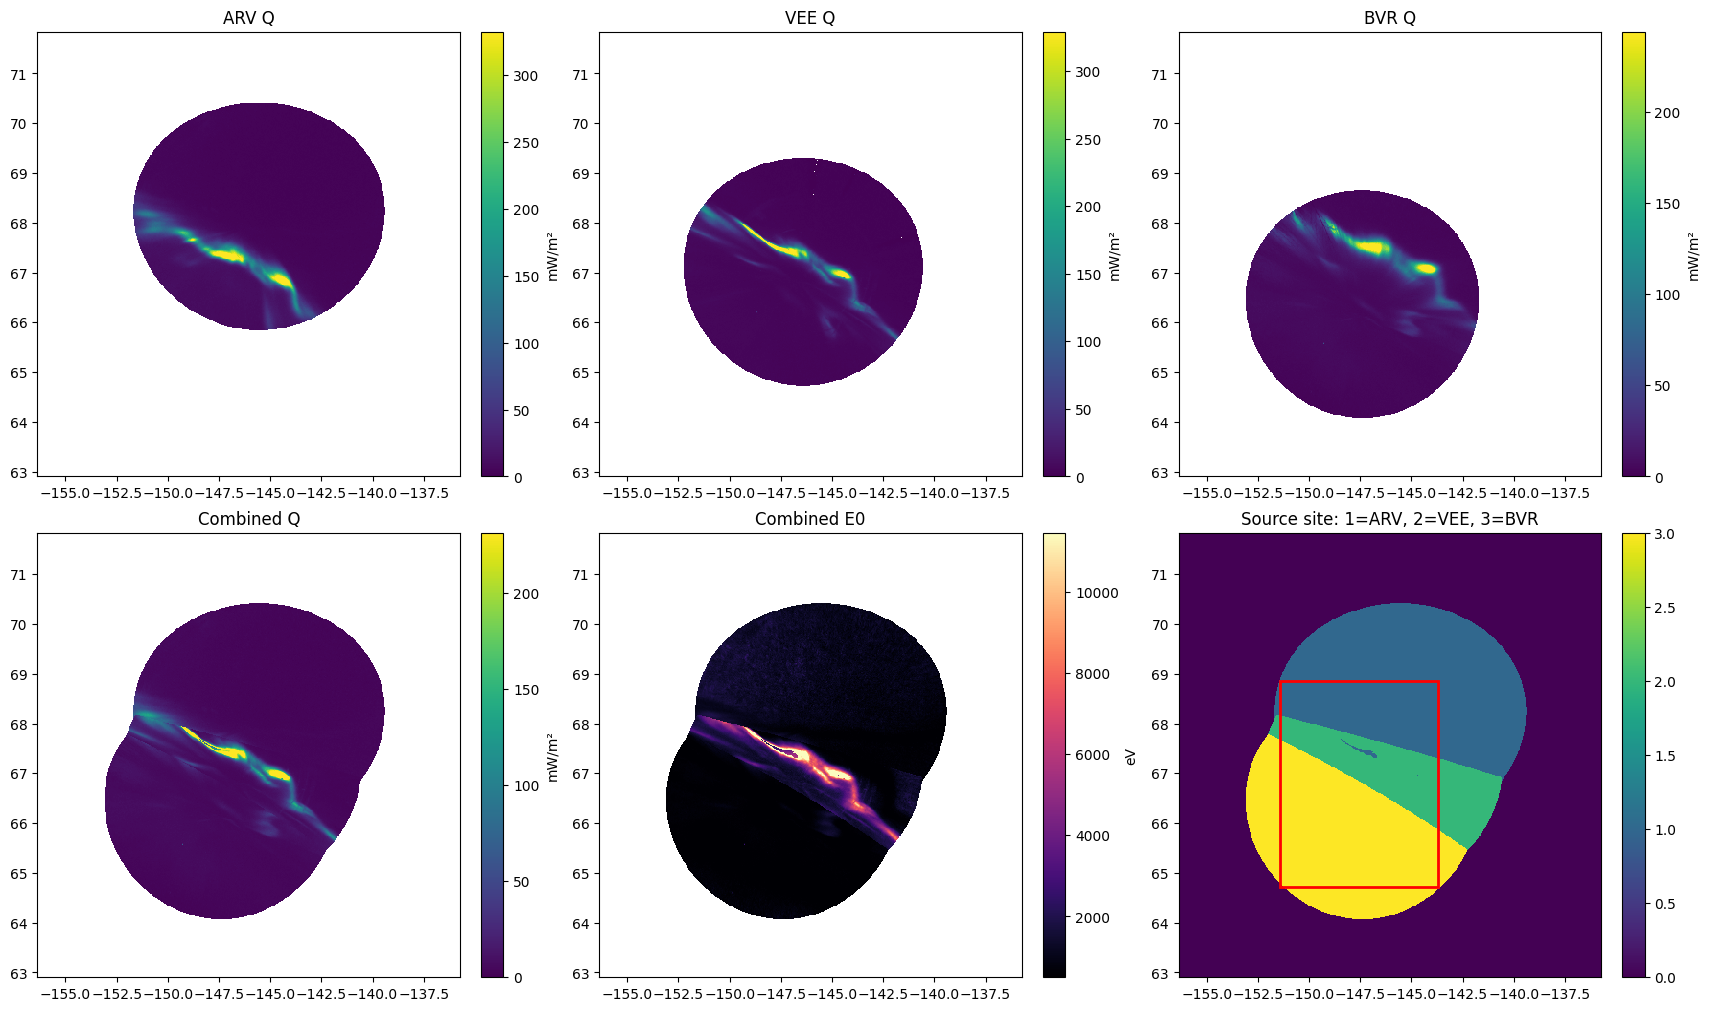

Diagnostic valid pixels by site:
  ARV: 52,259
  VEE: 49,715
  BVR: 48,560
Combined valid pixels: 77,243
Pixels with multiple valid site inversions: 49,064


In [119]:
diagnostic_result = process_time(parse_utc(diagnostic_time), collect_diagnostics=True)
# Assign every grid cell one exclusive outcome, using the first stage that fails.
failure_labels = (
    'Neither red nor green mapped',
    'Red missing',
    'Green missing',
    'Red or green <= 0',
    'Ratio outside GLOW envelope',
    'Q inversion failed',
    'E0 has no/ambiguous solution',
    'SigP/SigH outside lookup',
    'Valid inversion',
)
failure_colors = (
    '#d9d9d9', '#e41a1c', '#377eb8', '#984ea3', '#ff7f00',
    '#ffff33', '#a65628', '#f781bf', '#4daf4a',
)
failure_cmap = ListedColormap(failure_colors)
failure_norm = BoundaryNorm(np.arange(-0.5, len(failure_labels) + 0.5), len(failure_labels))

def classify_inversion_outcome(diagnostics):
    red_finite = diagnostics['red_finite']
    green_finite = diagnostics['green_finite']
    positive = diagnostics['positive_rg']
    ratio_ok = diagnostics['ratio_in_lookup']
    q_finite = diagnostics['q_finite']
    e0_finite = diagnostics['e0_finite']
    outcome = np.zeros(red_finite.shape, dtype=np.uint8)
    outcome[~red_finite & green_finite] = 1
    outcome[red_finite & ~green_finite] = 2
    outcome[red_finite & green_finite & ~positive] = 3
    outcome[positive & ~ratio_ok] = 4
    outcome[ratio_ok & ~q_finite] = 5
    outcome[ratio_ok & q_finite & ~e0_finite] = 6
    qe_valid = ratio_ok & q_finite & e0_finite
    if diagnostics['sigp_finite'] is not None:
        conductance_valid = diagnostics['sigp_finite'] & diagnostics['sigh_finite']
        outcome[qe_valid & ~conductance_valid] = 7
        outcome[qe_valid & conductance_valid] = 8
    else:
        outcome[qe_valid] = 8
    return outcome

fig, axes = plt.subplots(1, len(sites), figsize=(18, 6), constrained_layout=True)
for axis, site in zip(axes, sites):
    outcome = classify_inversion_outcome(diagnostic_result['sites'][site]['diagnostics'])
    axis.pcolormesh(
        decgridlon, decgridlat, outcome, shading='nearest',
        cmap=failure_cmap, norm=failure_norm,
    )
    axis.set_title(f'{site}: inversion outcome at {diagnostic_time} UTC')
    axis.set_xlabel('Longitude')
    axis.set_ylabel('Latitude')
    print(f'\n{site} outcome counts:')
    for code, label in enumerate(failure_labels):
        count = np.count_nonzero(outcome == code)
        if count:
            print(f'  {label}: {count:,}')
legend_handles = [Patch(facecolor=color, label=label) for color, label in zip(failure_colors, failure_labels)]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.show()

# Diagnose pixels that remain NaN after nearest-valid-site combination.
site_diagnostics = [diagnostic_result['sites'][site]['diagnostics'] for site in sites]
rg_coverage_stack = np.stack([
    diagnostics['red_finite'] & diagnostics['green_finite']
    for diagnostics in site_diagnostics
])
positive_stack = np.stack([diagnostics['positive_rg'] for diagnostics in site_diagnostics])
ratio_stack = np.stack([diagnostics['ratio_in_lookup'] for diagnostics in site_diagnostics])
q_stack = np.stack([
    diagnostics['ratio_in_lookup'] & diagnostics['q_finite']
    for diagnostics in site_diagnostics
])
valid_stack = np.stack([diagnostic_result['sites'][site]['valid'] for site in sites])
rg_coverage_count = np.sum(rg_coverage_stack, axis=0)
valid_site_count = np.sum(valid_stack, axis=0)
combined_nan = (
    ~np.isfinite(diagnostic_result['combined']['q'])
    | ~np.isfinite(diagnostic_result['combined']['e0'])
)
combined_nan_reason = np.full(decgridlat.shape, np.nan)
combined_nan_reason[combined_nan & ~np.any(rg_coverage_stack, axis=0)] = 0
combined_nan_reason[combined_nan & np.any(rg_coverage_stack, axis=0)] = 1
combined_nan_reason[combined_nan & np.any(positive_stack, axis=0)] = 2
combined_nan_reason[combined_nan & np.any(ratio_stack, axis=0)] = 3
combined_nan_reason[combined_nan & np.any(q_stack, axis=0)] = 4
combined_nan_labels = (
    'Outside every red/green overlap',
    'Covered, but red or green is nonpositive',
    'All covering sites outside GLOW ratio envelope',
    'Ratio accepted, but Q failed at every site',
    'Q found, but E0 failed at every site',
)
combined_nan_colors = ('#d9d9d9', '#984ea3', '#ff7f00', '#ffff33', '#a65628')
combined_outcome = np.full(decgridlat.shape, 8, dtype=np.uint8)
combined_outcome[combined_nan_reason == 0] = 0
combined_outcome[combined_nan_reason == 1] = 3
combined_outcome[combined_nan_reason == 2] = 4
combined_outcome[combined_nan_reason == 3] = 5
combined_outcome[combined_nan_reason == 4] = 6
# Assign camera ownership from geometry/coverage before considering inversion validity.
# A failed VEE pixel therefore remains in VEE's slice instead of falling back to ARV or BVR.
geometric_distances = np.stack([
    np.where(rg_coverage_stack[index], site_distance_km[site], np.inf)
    for index, site in enumerate(sites)
])
geometric_owner = np.argmin(geometric_distances, axis=0)
has_geometric_owner = np.any(rg_coverage_stack, axis=0)
fig, axes = plt.subplots(1, len(sites), figsize=(19, 6), constrained_layout=True)
print('\nFixed geometric ownership slices:')
for site_index, (axis, site) in enumerate(zip(axes, sites)):
    owned = has_geometric_owner & (geometric_owner == site_index)
    site_outcome = classify_inversion_outcome(
        diagnostic_result['sites'][site]['diagnostics']
    )
    owned_outcome = np.where(owned, site_outcome.astype(float), np.nan)
    axis.pcolormesh(
        decgridlon, decgridlat, owned_outcome, shading='nearest',
        cmap=failure_cmap, norm=failure_norm,
    )
    axis.set_title(f'{site}: fixed ownership slice')
    axis.set_xlabel('Longitude')
    axis.set_ylabel('Latitude')
    print(f'  {site}: {np.count_nonzero(owned):,} owned pixels')
    for code, outcome_label in enumerate(failure_labels):
        count = np.count_nonzero(owned & (site_outcome == code))
        if count and code != 0:
            print(f'    {outcome_label}: {count:,}')
ownership_legend_codes = (1, 2, 3, 4, 5, 6, 7, 8)
fig.legend(
    handles=[Patch(facecolor=failure_colors[code], label=failure_labels[code])
             for code in ownership_legend_codes],
    loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=4,
)
fig.suptitle(f'Fixed camera slices after red/green overlap at {diagnostic_time} UTC')
plt.show()

# Focused VEE red/green registration check inside VEE's fixed ownership slice.
vee_index = sites.index('VEE')
vee_owned = has_geometric_owner & (geometric_owner == vee_index)
vee_diagnostics = diagnostic_result['sites']['VEE']['diagnostics']
vee_red = vee_diagnostics['observed_red']
vee_green = vee_diagnostics['observed_green']
vee_outcome = classify_inversion_outcome(vee_diagnostics)
vee_ratio_failure = vee_owned & (vee_outcome == 4)
vee_red_values = vee_red[vee_owned & np.isfinite(vee_red) & (vee_red > 0)]
vee_green_values = vee_green[vee_owned & np.isfinite(vee_green) & (vee_green > 0)]
vee_red_scale = np.percentile(vee_red_values, 99)
vee_green_scale = np.percentile(vee_green_values, 99)
vee_red_normalized = np.where(vee_owned, np.clip(vee_red / vee_red_scale, 0, 1), np.nan)
vee_green_normalized = np.where(vee_owned, np.clip(vee_green / vee_green_scale, 0, 1), np.nan)
registration_levels = (0.25, 0.5, 0.75, 0.9)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
for axis in axes:
    axis.pcolormesh(
        decgridlon, decgridlat, np.where(vee_owned, vee_green_normalized, np.nan),
        shading='nearest', cmap='Greys', vmin=0, vmax=1, alpha=0.35,
    )
    axis.contour(
        decgridlon, decgridlat, vee_red_normalized, levels=registration_levels,
        colors='#d73027', linewidths=1.7,
    )
    axis.contour(
        decgridlon, decgridlat, vee_green_normalized, levels=registration_levels,
        colors='#1a9850', linewidths=1.7, linestyles='--',
    )
    axis.scatter(
        decgridlon[vee_ratio_failure], decgridlat[vee_ratio_failure],
        s=5, color=failure_colors[4], marker='s', linewidths=0,
        label='Ratio outside GLOW envelope', zorder=4,
    )
    axis.set_xlabel('Longitude')
    axis.set_ylabel('Latitude')
axes[0].set_title('VEE fixed slice: normalized red/green contours')
axes[1].set_title('Close-up of VEE ratio-failure streak')
if np.any(vee_ratio_failure):
    failure_lons = decgridlon[vee_ratio_failure]
    failure_lats = decgridlat[vee_ratio_failure]
    lon_padding = max(0.25, 0.2 * np.ptp(failure_lons))
    lat_padding = max(0.15, 0.2 * np.ptp(failure_lats))
    axes[1].set_xlim(np.min(failure_lons) - lon_padding, np.max(failure_lons) + lon_padding)
    axes[1].set_ylim(np.min(failure_lats) - lat_padding, np.max(failure_lats) + lat_padding)
else:
    axes[1].text(0.5, 0.5, 'No VEE ratio-envelope failures',
                 transform=axes[1].transAxes, ha='center', va='center')
registration_handles = (
    Patch(facecolor='none', edgecolor='#d73027', label='Red contours'),
    Patch(facecolor='none', edgecolor='#1a9850', label='Green contours (dashed)'),
    Patch(facecolor=failure_colors[4], label='Ratio outside GLOW envelope'),
)
for axis in axes:
    axis.legend(handles=registration_handles, loc='best')
fig.suptitle(
    f'VEE red/green registration at {diagnostic_time} UTC; '
    f'contours at {registration_levels}'
)
plt.show()
print(
    f'Vee registration scales (99th percentile): red={vee_red_scale:.1f} R, '
    f'green={vee_green_scale:.1f} R; ratio-failure pixels={np.count_nonzero(vee_ratio_failure):,}'
)

# Sweep VEE's assumed 630.0-nm emission altitude without changing production settings.
vee_red_altitudes_km = np.arange(120.0, 241.0, 20.0)
vee_red_native, _vee_red_files, _vee_red_indices, _vee_red_times = coadd_closest_frames(
    'VEE', 'red', parse_utc(diagnostic_time)
)
vee_red_skymap = red_skymaps_by_site['VEE']
vee_red_background, vee_red_sigma = estimate_background(
    vee_red_native, vee_red_skymap['elev']
)
vee_native_valid = ~np.asarray(vee_red_skymap['mask'], dtype=bool)
vee_red_prepared = denoise_image(
    vee_red_native, ~vee_native_valid, vee_red_background, vee_red_sigma,
    wavelet_max_shifts['red'],
)
vee_red_calibration = site_config['VEE']['calibration_r_s_per_count']['red']
vee_red_exposure = site_config['VEE']['exposure_seconds']['red']
vee_green_full_normalized = np.where(
    np.isfinite(vee_green) & (vee_green > 0),
    np.clip(vee_green / np.percentile(vee_green[np.isfinite(vee_green) & (vee_green > 0)], 99), 0, 1),
    np.nan,
)
vee_altitude_results = []
for red_altitude_km in vee_red_altitudes_km:
    trial_lat, trial_lon = azel2geo(
        site_config['VEE']['latitude'], site_config['VEE']['longitude'],
        vee_red_skymap['azmt'], vee_red_skymap['elev'], alt=red_altitude_km,
    )
    trial_valid = (
        vee_native_valid & np.isfinite(trial_lat) & np.isfinite(trial_lon)
    )
    trial_common_lat = np.full(trial_lat.shape, np.nan)
    trial_common_lon = np.full(trial_lon.shape, np.nan)
    trial_common_lat[trial_valid], trial_common_lon[trial_valid], _ = apex.map_to_height(
        trial_lat[trial_valid], trial_lon[trial_valid], red_altitude_km,
        common_mapping_altitude_km,
    )
    trial_coordinate_valid = (
        trial_valid & np.isfinite(trial_common_lat) & np.isfinite(trial_common_lon)
    )
    trial_red = regrid_channel(
        vee_red_prepared, trial_common_lat, trial_common_lon,
        trial_coordinate_valid, precomputed=None,
    )
    trial_red = (trial_red - vee_red_background) / vee_red_exposure * vee_red_calibration
    trial_red = trial_red[::decimation, ::decimation]
    trial_red_valid = np.isfinite(trial_red) & (trial_red > 0)
    trial_red_scale = np.percentile(trial_red[trial_red_valid], 99)
    trial_red_normalized = np.where(
        trial_red_valid, np.clip(trial_red / trial_red_scale, 0, 1), np.nan
    )
    trial_comparison = (
        np.isfinite(trial_red_normalized) & np.isfinite(vee_green_full_normalized)
        & ((trial_red_normalized >= 0.15) | (vee_green_full_normalized >= 0.15))
    )
    trial_correlation = np.corrcoef(
        trial_red_normalized[trial_comparison],
        vee_green_full_normalized[trial_comparison],
    )[0, 1]
    trial_rmse = np.sqrt(np.mean(
        (trial_red_normalized[trial_comparison] - vee_green_full_normalized[trial_comparison]) ** 2
    ))
    vee_altitude_results.append({
        'altitude_km': red_altitude_km, 'red_normalized': trial_red_normalized,
        'correlation': trial_correlation, 'normalized_rmse': trial_rmse,
    })

vee_geographic_zenith_lat = site_config['VEE']['latitude']
vee_geographic_zenith_lon = site_config['VEE']['longitude']
vee_magnetic_zenith_lat, vee_magnetic_zenith_lon, _ = apex.map_to_height(
    vee_geographic_zenith_lat, vee_geographic_zenith_lon, 0.0,
    common_mapping_altitude_km,
)
zenith_handles = (
    Line2D(
        [0], [0], marker='+', linestyle='none', color='black',
        markersize=11, markeredgewidth=2, label='Geographic zenith',
    ),
    Line2D(
        [0], [0], marker='x', linestyle='none', color='#2c7fb8',
        markersize=9, markeredgewidth=2,
        label=f'Magnetic zenith ({common_mapping_altitude_km:.0f} km)',
    ),
)

fig, axes = plt.subplots(2, 4, figsize=(20, 11), constrained_layout=True)
axes = axes.ravel()
for axis, altitude_result in zip(axes, vee_altitude_results):
    axis.contour(
        decgridlon, decgridlat, altitude_result['red_normalized'],
        levels=registration_levels, colors='#d73027', linewidths=1.5,
    )
    axis.contour(
        decgridlon, decgridlat, vee_green_full_normalized,
        levels=registration_levels, colors='#1a9850', linewidths=1.5,
        linestyles='--',
    )
    axis.scatter(
        vee_geographic_zenith_lon, vee_geographic_zenith_lat,
        marker='+', s=130, linewidths=2, color='black', zorder=5,
    )
    axis.scatter(
        vee_magnetic_zenith_lon, vee_magnetic_zenith_lat,
        marker='x', s=90, linewidths=2, color='#2c7fb8', zorder=5,
    )
    axis.set_title(
        f"Red altitude {altitude_result['altitude_km']:.0f} km\n"
        f"corr={altitude_result['correlation']:.3f}, "
        f"RMSE={altitude_result['normalized_rmse']:.3f}"
    )
    if np.any(vee_ratio_failure):
        axis.set_xlim(np.min(failure_lons) - lon_padding, np.max(failure_lons) + lon_padding)
        axis.set_ylim(np.min(failure_lats) - lat_padding, 68.2)
    axis.set_xlabel('Longitude')
    axis.set_ylabel('Latitude')
for axis in axes[len(vee_altitude_results):]:
    axis.set_visible(False)
fig.legend(
    handles=registration_handles[:2] + zenith_handles,
    loc='lower center', ncol=4,
)
fig.suptitle(f'VEE red emission-altitude sweep at {diagnostic_time} UTC')
plt.show()
best_altitude_correlation = max(
    vee_altitude_results, key=lambda result: result['correlation']
)
best_altitude_rmse = min(
    vee_altitude_results, key=lambda result: result['normalized_rmse']
)
print('VEE red emission-altitude comparison:')
for altitude_result in vee_altitude_results:
    print(
        f"  {altitude_result['altitude_km']:.0f} km: "
        f"corr={altitude_result['correlation']:.3f}, "
        f"RMSE={altitude_result['normalized_rmse']:.3f}"
    )
print(f"Best correlation altitude: {best_altitude_correlation['altitude_km']:.0f} km")
print(f"Lowest RMSE altitude: {best_altitude_rmse['altitude_km']:.0f} km")

def classify_e0_failure_reasons(site_result, lookup):
    diagnostics = site_result['diagnostics']
    failed = (
        diagnostics['ratio_in_lookup'] & diagnostics['q_finite']
        & ~diagnostics['e0_finite']
    )
    reasons = np.full(failed.shape, np.nan)
    lookup_red = lookup['redmat'] - lookup['redbright_airglow'][0][0]
    lookup_green = lookup['greenmat'] - lookup['greenbright_airglow'][0][0]
    lookup_ratio = np.divide(
        lookup_red, lookup_green,
        out=np.full_like(lookup_red, np.nan, dtype=float),
        where=np.isfinite(lookup_green) & (lookup_green != 0),
    )
    q_values = lookup['Qvec']
    e0_values = lookup['E0vec']
    observed = diagnostics['observed_ratio']
    inferred_q = site_result['q']
    for flat_index in np.flatnonzero(failed):
        q_value = inferred_q.flat[flat_index]
        observed_value = observed.flat[flat_index]
        lower_indices = np.flatnonzero(q_values < q_value)
        if lower_indices.size == 0 or lower_indices[-1] == len(q_values) - 1:
            reasons.flat[flat_index] = 0  # Q cannot be bracketed
            continue
        q_index = lower_indices[-1]
        q_fraction = (
            (q_value - q_values[q_index])
            / (q_values[q_index + 1] - q_values[q_index])
        )
        ratio_curve = (
            (1 - q_fraction) * lookup_ratio[:, q_index]
            + q_fraction * lookup_ratio[:, q_index + 1]
            - observed_value
        )
        crossings = np.flatnonzero(np.diff(np.sign(ratio_curve)))
        if crossings.size == 0:
            reasons.flat[flat_index] = 1  # No E0 crossing at this Q
            continue
        ambiguous = crossings.size > 2 or (
            crossings.size > 1 and np.diff(crossings)[0] != 1
        )
        if ambiguous:
            reasons.flat[flat_index] = 2  # Multiple separated crossings
            continue
        crossing = crossings[0]
        slope = (
            (ratio_curve[crossing + 1] - ratio_curve[crossing])
            / (e0_values[crossing + 1] - e0_values[crossing])
        )
        if not np.isfinite(slope) or slope == 0:
            reasons.flat[flat_index] = 3  # Numerical interpolation failure
        else:
            reasons.flat[flat_index] = 3  # Unexpected numerical failure
    return reasons

e0_reason_labels = (
    'Q outside interpolation bracket',
    'No E0 crossing at inferred Q',
    'Multiple separated E0 crossings',
    'Numerical interpolation failure',
)
e0_reason_colors = ('#377eb8', '#e41a1c', '#984ea3', '#ff7f00')
arv_e0_failure_reasons = classify_e0_failure_reasons(
    diagnostic_result['sites']['ARV'], lookup_by_site['ARV']
)
show_arv_e0_failure_diagnostic = False
if show_arv_e0_failure_diagnostic and np.any(np.isfinite(arv_e0_failure_reasons)):
    fig, axis = plt.subplots(figsize=(9, 7), constrained_layout=True)
    reason_plot = axis.pcolormesh(
        decgridlon, decgridlat, arv_e0_failure_reasons, shading='nearest',
        cmap=ListedColormap(e0_reason_colors),
        norm=BoundaryNorm(np.arange(-0.5, len(e0_reason_labels) + 0.5), len(e0_reason_labels)),
    )
    axis.set_title(f'ARV E0 failure reasons at {diagnostic_time} UTC')
    axis.set_xlabel('Longitude')
    axis.set_ylabel('Latitude')
    reason_handles = [
        Patch(facecolor=color, label=reason_label)
        for color, reason_label in zip(e0_reason_colors, e0_reason_labels)
    ]
    axis.legend(handles=reason_handles, loc='best')
    plt.show()
    print('ARV E0 failure reasons:')
    for reason_code, reason_label in enumerate(e0_reason_labels):
        reason_count = np.count_nonzero(arv_e0_failure_reasons == reason_code)
        if reason_count:
            print(f'  {reason_label}: {reason_count:,}')
    arv_q = diagnostic_result['sites']['ARV']['q']
    arv_q_outside = arv_e0_failure_reasons == 0
    q_min = float(np.nanmin(lookup_by_site['ARV']['Qvec']))
    q_max = float(np.nanmax(lookup_by_site['ARV']['Qvec']))
    q_span = q_max - q_min
    q_bracket_direction = np.full(arv_q.shape, np.nan)
    q_bracket_direction[arv_q_outside & (arv_q < q_min)] = -1
    q_bracket_direction[arv_q_outside & (arv_q > q_max)] = 1
    q_fraction_outside = np.full(arv_q.shape, np.nan)
    if q_span > 0:
        below_q = arv_q_outside & (arv_q < q_min)
        above_q = arv_q_outside & (arv_q > q_max)
        q_fraction_outside[below_q] = (q_min - arv_q[below_q]) / q_span
        q_fraction_outside[above_q] = (arv_q[above_q] - q_max) / q_span

    if np.any(np.isfinite(q_bracket_direction)):
        fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
        axes[0].pcolormesh(
            decgridlon, decgridlat, q_bracket_direction, shading='nearest',
            cmap=ListedColormap(('#2166ac', '#b2182b')),
            norm=BoundaryNorm((-1.5, 0, 1.5), 2),
        )
        axes[0].set_title('ARV Q bracket direction')
        axes[0].legend(
            handles=(Patch(facecolor='#2166ac', label='Below Q minimum'),
                     Patch(facecolor='#b2182b', label='Above Q maximum')),
            loc='best',
        )
        distance_plot = axes[1].pcolormesh(
            decgridlon, decgridlat, q_fraction_outside, shading='nearest', cmap='magma',
        )
        axes[1].set_title('Distance outside Q bracket / full Q span')
        fig.colorbar(distance_plot, ax=axes[1], label='Fraction of lookup Q span')
        for axis in axes:
            axis.set_xlabel('Longitude')
            axis.set_ylabel('Latitude')
        fig.suptitle(f'ARV Q-bracket failures at {diagnostic_time} UTC')
        plt.show()
        print(f'ARV lookup Q range: {q_min:g} to {q_max:g}')
        print(f'  Below Q minimum: {np.count_nonzero(q_bracket_direction == -1):,}')
        print(f'  Above Q maximum: {np.count_nonzero(q_bracket_direction == 1):,}')
        finite_distance = q_fraction_outside[np.isfinite(q_fraction_outside)]
        print(
            '  Fractional distance outside (min / median / max): '
            f'{np.min(finite_distance):.3g} / {np.median(finite_distance):.3g} / '
            f'{np.max(finite_distance):.3g}'
        )

        arv_diagnostics = diagnostic_result['sites']['ARV']['diagnostics']
        if 'observed_red' in arv_diagnostics and 'observed_green' in arv_diagnostics:
            observed_red = arv_diagnostics['observed_red']
            observed_green = arv_diagnostics['observed_green']
        else:
            # Support kernels that still have the older invert_site definition loaded.
            diagnostic_target = parse_utc(diagnostic_time)
            observed_red, _ = process_channel('ARV', 'red', diagnostic_target)
            observed_green, _ = process_channel('ARV', 'green', diagnostic_target)
            observed_red = observed_red[::decimation, ::decimation]
            observed_green = observed_green[::decimation, ::decimation]
        observed_positive = (
            np.isfinite(observed_red) & np.isfinite(observed_green)
            & (observed_red > 0) & (observed_green > 0)
        )
        lookup = lookup_by_site['ARV']
        lookup_red = lookup['redmat'] - lookup['redbright_airglow'][0][0]
        lookup_green = lookup['greenmat'] - lookup['greenbright_airglow'][0][0]
        lookup_positive = (
            np.isfinite(lookup_red) & np.isfinite(lookup_green)
            & (lookup_red > 0) & (lookup_green > 0)
        )
        lookup_rows, lookup_columns = np.where(lookup_positive)
        display_step = max(1, lookup_rows.size // 30000)
        display_indices = np.arange(0, lookup_rows.size, display_step)
        qmax_column = int(np.nanargmax(lookup['Qvec']))
        qmax_valid = (
            np.isfinite(lookup_red[:, qmax_column])
            & np.isfinite(lookup_green[:, qmax_column])
            & (lookup_red[:, qmax_column] > 0)
            & (lookup_green[:, qmax_column] > 0)
        )

        fig, axis = plt.subplots(figsize=(9, 8), constrained_layout=True)
        axis.scatter(
            np.log10(lookup_red[lookup_rows[display_indices], lookup_columns[display_indices]]),
            np.log10(lookup_green[lookup_rows[display_indices], lookup_columns[display_indices]]),
            s=3, color='0.75', alpha=0.35, linewidths=0, label='GLOW lookup cloud',
        )
        axis.plot(
            np.log10(lookup_red[qmax_valid, qmax_column]),
            np.log10(lookup_green[qmax_valid, qmax_column]),
            color='#1b9e77', linewidth=2.5, label=f'GLOW Q max = {q_max:g}',
        )
        axis.scatter(
            np.log10(observed_red[observed_positive]),
            np.log10(observed_green[observed_positive]),
            s=5, color='black', alpha=0.12, linewidths=0, label='All valid ARV pixels',
        )
        failed_points = arv_q_outside & observed_positive
        failed_scatter = axis.scatter(
            np.log10(observed_red[failed_points]),
            np.log10(observed_green[failed_points]),
            c=arv_q[failed_points], s=16, cmap='plasma', edgecolors='none',
            label='Q-above-maximum pixels', zorder=3,
        )
        fig.colorbar(failed_scatter, ax=axis, label='Extrapolated Q')
        axis.set_title(f'ARV observations versus GLOW brightness space at {diagnostic_time} UTC')
        axis.set_xlabel('log10(red brightness)')
        axis.set_ylabel('log10(green brightness)')
        axis.legend(loc='best')
        plt.show()
elif show_arv_e0_failure_diagnostic:
    print(f'No ARV E0 interpolation failures at {diagnostic_time} UTC.')

ratio_direction_labels = ('Below GLOW ratio minimum', 'Above GLOW ratio maximum')
ratio_direction_colors = ('#2166ac', '#b2182b')
fig, axes = plt.subplots(2, len(sites), figsize=(18, 12), constrained_layout=True)
diagnostic_target = parse_utc(diagnostic_time)
for column, site in enumerate(sites):
    site_result = diagnostic_result['sites'][site]
    diagnostics = site_result['diagnostics']
    if 'observed_red' in diagnostics and 'observed_green' in diagnostics:
        observed_red = diagnostics['observed_red']
        observed_green = diagnostics['observed_green']
        red_metadata = site_result['red_metadata']
        green_metadata = site_result['green_metadata']
    else:
        observed_red, red_metadata = process_channel(site, 'red', diagnostic_target)
        observed_green, green_metadata = process_channel(site, 'green', diagnostic_target)
        observed_red = observed_red[::decimation, ::decimation]
        observed_green = observed_green[::decimation, ::decimation]

    ratio = diagnostics['observed_ratio']
    ratio_min, ratio_max = diagnostics['lookup_ratio_bounds']
    positive = diagnostics['positive_rg']
    ratio_direction = np.full(ratio.shape, np.nan)
    ratio_direction[positive & (ratio < ratio_min)] = -1
    ratio_direction[positive & (ratio > ratio_max)] = 1
    axes[0, column].pcolormesh(
        decgridlon, decgridlat, ratio_direction, shading='nearest',
        cmap=ListedColormap(ratio_direction_colors),
        norm=BoundaryNorm((-1.5, 0, 1.5), 2),
    )
    axes[0, column].set_title(f'{site}: ratio-envelope direction')
    axes[0, column].legend(
        handles=[Patch(facecolor=color, label=label)
                 for color, label in zip(ratio_direction_colors, ratio_direction_labels)],
        loc='best',
    )

    red_scale = np.nanpercentile(observed_red[observed_red > 0], 99)
    green_scale = np.nanpercentile(observed_green[observed_green > 0], 99)
    red_normalized = np.clip(observed_red / red_scale, 0, 1)
    green_normalized = np.clip(observed_green / green_scale, 0, 1)
    contour_levels = (0.25, 0.5, 0.75)
    axes[1, column].contour(
        decgridlon, decgridlat, red_normalized, levels=contour_levels,
        colors='#d73027', linewidths=1.5,
    )
    axes[1, column].contour(
        decgridlon, decgridlat, green_normalized, levels=contour_levels,
        colors='#1a9850', linewidths=1.5, linestyles='--',
    )
    axes[1, column].set_title(f'{site}: normalized red/green contours')
    axes[1, column].legend(
        handles=(Patch(facecolor='none', edgecolor='#d73027', label='Red'),
                 Patch(facecolor='none', edgecolor='#1a9850', label='Green (dashed)')),
        loc='best',
    )
    for row in range(2):
        axes[row, column].set_xlabel('Longitude')
        axes[row, column].set_ylabel('Latitude')

    below_count = np.count_nonzero(ratio_direction == -1)
    above_count = np.count_nonzero(ratio_direction == 1)
    red_times = ', '.join(str(value.time()) for value in red_metadata['frame_times'])
    green_times = ', '.join(str(value.time()) for value in green_metadata['frame_times'])
    print(f'\n{site} GLOW ratio range: {ratio_min:.4g} to {ratio_max:.4g}')
    print(f'  Below minimum: {below_count:,}; above maximum: {above_count:,}')
    print(f'  Red frame times: {red_times}')
    print(f'  Green frame times: {green_times}')
plt.close(fig)

fig, axes = plt.subplots(len(sites), 3, figsize=(18, 15), constrained_layout=True)
for row, site in enumerate(sites):
    site_result = diagnostic_result['sites'][site]
    diagnostics = site_result['diagnostics']
    if 'observed_red' in diagnostics and 'observed_green' in diagnostics:
        observed_red = diagnostics['observed_red']
        observed_green = diagnostics['observed_green']
    else:
        observed_red, _ = process_channel(site, 'red', diagnostic_target)
        observed_green, _ = process_channel(site, 'green', diagnostic_target)
        observed_red = observed_red[::decimation, ::decimation]
        observed_green = observed_green[::decimation, ::decimation]

    ratio = diagnostics['observed_ratio']
    ratio_min, _ratio_max = diagnostics['lookup_ratio_bounds']
    below_ratio = diagnostics['positive_rg'] & (ratio < ratio_min)
    fractional_below = np.full(ratio.shape, np.nan)
    if ratio_min > 0:
        fractional_below[below_ratio] = (ratio_min - ratio[below_ratio]) / ratio_min
    finite_fraction = fractional_below[np.isfinite(fractional_below)]
    fraction_vmax = np.percentile(finite_fraction, 99.5) if finite_fraction.size else 1

    red_plot = axes[row, 0].pcolormesh(
        decgridlon, decgridlat, observed_red, shading='nearest',
        vmin=0, vmax=finite_percentile(observed_red), cmap='inferno',
    )
    green_plot = axes[row, 1].pcolormesh(
        decgridlon, decgridlat, observed_green, shading='nearest',
        vmin=0, vmax=finite_percentile(observed_green), cmap='viridis',
    )
    fraction_plot = axes[row, 2].pcolormesh(
        decgridlon, decgridlat, fractional_below, shading='nearest', cmap='magma',
        vmin=0, vmax=fraction_vmax,
    )
    fig.colorbar(red_plot, ax=axes[row, 0], label='Rayleighs')
    fig.colorbar(green_plot, ax=axes[row, 1], label='Rayleighs')
    fig.colorbar(fraction_plot, ax=axes[row, 2], label='(ratio min - observed ratio) / ratio min')
    axes[row, 0].set_title(f'{site}: processed red input')
    axes[row, 1].set_title(f'{site}: processed green input')
    axes[row, 2].set_title(f'{site}: fractional distance below ratio minimum')
    for axis in axes[row]:
        axis.set_xlabel('Longitude')
        axis.set_ylabel('Latitude')

    if finite_fraction.size:
        print(
            f'{site} fractional distance below ratio minimum '
            f'(min / median / 95th / max): {np.min(finite_fraction):.3g} / '
            f'{np.median(finite_fraction):.3g} / {np.percentile(finite_fraction, 95):.3g} / '
            f'{np.max(finite_fraction):.3g}'
        )
    else:
        print(f'{site}: no ratios below the GLOW minimum.')
plt.close(fig)

fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)
for column, site in enumerate(sites):
    site_q = diagnostic_result['sites'][site]['q']
    handle = axes[0, column].pcolormesh(
        decgridlon, decgridlat, site_q,
        shading='nearest', vmin=0, vmax=finite_percentile(site_q),
    )
    axes[0, column].set_title(f'{site} Q')
    fig.colorbar(handle, ax=axes[0, column], label='mW/m²')
combined_q_image = diagnostic_result['combined']['q']
combined_q = axes[1, 0].pcolormesh(
    decgridlon, decgridlat, combined_q_image,
    shading='nearest', vmin=0, vmax=finite_percentile(combined_q_image),
)
axes[1, 0].set_title('Combined Q')
fig.colorbar(combined_q, ax=axes[1, 0], label='mW/m²')
combined_e0_image = diagnostic_result['combined']['e0']
combined_e0 = axes[1, 1].pcolormesh(
    decgridlon, decgridlat, combined_e0_image,
    shading='nearest', cmap='magma', vmin=500,
    vmax=finite_percentile(combined_e0_image),
)
axes[1, 1].set_title('Combined E0')
fig.colorbar(combined_e0, ax=axes[1, 1], label='eV')
source = axes[1, 2].pcolormesh(
    decgridlon, decgridlat, diagnostic_result['combined']['source_site'],
    shading='nearest', vmin=0, vmax=3, cmap='viridis',
)
axes[1, 2].set_title('Source site: 1=ARV, 2=VEE, 3=BVR')
axes[1, 2].add_patch(Rectangle(
    (-151.42, 64.71), 151.42 - 143.68, 68.86 - 64.71,
    fill=False, edgecolor='red', linewidth=2,
))
fig.colorbar(source, ax=axes[1, 2])
plt.show()
ownership = diagnostic_result['combined']['ownership_count']
print('Diagnostic valid pixels by site:')
for site in sites:
    print(f"  {site}: {np.count_nonzero(diagnostic_result['sites'][site]['valid']):,}")
print('Combined valid pixels:', f"{np.count_nonzero(ownership > 0):,}")
print('Pixels with multiple valid site inversions:', f"{np.count_nonzero(ownership > 1):,}")

## Window-wide inversion quality scan

This read-only scan evaluates 09:50–10:30 UTC at 60-second cadence. It does not open or modify the HDF5 output file. Each pixel is assigned to the nearest camera with finite red and green coverage before inversion validity is considered. Site statistics use only these fixed ownership slices, and a failed owned pixel remains a combined hole instead of falling back to another camera.

In [70]:
exec(window_quality_scan_source, globals())

Quality scan [01/41] 09:50:00 UTC
Quality scan [02/41] 09:51:00 UTC
Quality scan [03/41] 09:52:00 UTC
Quality scan [04/41] 09:53:00 UTC
Quality scan [05/41] 09:54:00 UTC
Quality scan [06/41] 09:55:00 UTC
Quality scan [07/41] 09:56:00 UTC
Quality scan [08/41] 09:57:00 UTC
Quality scan [09/41] 09:58:00 UTC
Quality scan [10/41] 09:59:00 UTC
Quality scan [11/41] 10:00:00 UTC
Quality scan [12/41] 10:01:00 UTC
Quality scan [13/41] 10:02:00 UTC
Quality scan [14/41] 10:03:00 UTC
Quality scan [15/41] 10:04:00 UTC
Quality scan [16/41] 10:05:00 UTC
Quality scan [17/41] 10:06:00 UTC
Quality scan [18/41] 10:07:00 UTC
Quality scan [19/41] 10:08:00 UTC
Quality scan [20/41] 10:09:00 UTC
Quality scan [21/41] 10:10:00 UTC
Quality scan [22/41] 10:11:00 UTC
Quality scan [23/41] 10:12:00 UTC
Quality scan [24/41] 10:13:00 UTC
Quality scan [25/41] 10:14:00 UTC
Quality scan [26/41] 10:15:00 UTC
Quality scan [27/41] 10:16:00 UTC


KeyboardInterrupt: 

## Run or resume the launch-wide HDF5 series

In [71]:
def create_float_cube(group, name, shape):
    chunks = (1, min(shape[1], 128), min(shape[2], 128))
    return group.create_dataset(
        name, shape=shape, dtype='f4', chunks=chunks,
        compression='gzip', compression_opts=4, shuffle=True,
        fillvalue=np.nan,
    )

def initialize_output(h5):
    nt = len(target_times)
    cube_shape = (nt, *decgridlat.shape)
    h5.attrs['format'] = 'gneiss_multisite_rg_inversion'
    h5.attrs['schema_version'] = '1.2'
    h5.attrs['storage_mode'] = 'combined_only'
    h5.attrs['ownership_method'] = 'nearest_valid_site_after_independent_inversion'
    h5.attrs['date'] = date
    h5.attrs['start'] = start
    h5.attrs['end'] = end
    h5.attrs['step_seconds'] = step_seconds
    h5.attrs['apex_reference_time'] = f'{date}T{apex_reference_time}'
    h5.attrs['common_mapping_altitude_km'] = common_mapping_altitude_km
    h5.attrs['target_grid_spacing_km'] = target_grid_spacing_km
    h5.attrs['site_codes_json'] = json.dumps(site_codes)
    h5.attrs['calibration_json'] = json.dumps({
        site: site_config[site]['calibration_r_s_per_count'] for site in sites
    })
    h5.attrs['glow_params_json'] = json.dumps({
        site: lookup_by_site[site]['Params'][:8].tolist() for site in sites
    })
    h5.create_dataset('time_iso', data=np.asarray(
        [value.isoformat() for value in target_times], dtype='S26'
    ))
    h5.create_dataset('completed', shape=(nt,), dtype='?')
    h5.create_dataset('gridlat', data=decgridlat.astype('f4'))
    h5.create_dataset('gridlon', data=decgridlon.astype('f4'))
    combined = h5.create_group('combined')
    create_float_cube(combined, 'q_mW_m2', cube_shape)
    create_float_cube(combined, 'e0_eV', cube_shape)
    combined.create_dataset(
        'source_site', shape=cube_shape, dtype='u1',
        chunks=(1, min(cube_shape[1], 128), min(cube_shape[2], 128)),
        compression='gzip', compression_opts=4, shuffle=True,
    )
    combined.create_dataset(
        'ownership_count', shape=cube_shape, dtype='u1',
        chunks=(1, min(cube_shape[1], 128), min(cube_shape[2], 128)),
        compression='gzip', compression_opts=4, shuffle=True,
    )
    if calculate_conductances:
        create_float_cube(combined, 'sigp_S', cube_shape)
        create_float_cube(combined, 'sigh_S', cube_shape)
    h5['gridlat'].attrs['coordinate_system'] = 'geodetic'
    h5['gridlat'].attrs['units'] = 'degrees_north'
    h5['gridlon'].attrs['coordinate_system'] = 'geodetic'
    h5['gridlon'].attrs['units'] = 'degrees_east'
    combined['q_mW_m2'].attrs['units'] = 'mW m-2'
    combined['e0_eV'].attrs['units'] = 'eV'
    if calculate_conductances:
        combined['sigp_S'].attrs['units'] = 'S'
        combined['sigh_S'].attrs['units'] = 'S'

def write_time_result(h5, index, result):
    combined = result['combined']
    h5['combined/q_mW_m2'][index] = combined['q'].astype('f4')
    h5['combined/e0_eV'][index] = combined['e0'].astype('f4')
    h5['combined/source_site'][index] = combined['source_site']
    h5['combined/ownership_count'][index] = combined['ownership_count']
    if calculate_conductances:
        h5['combined/sigp_S'][index] = combined['sigp'].astype('f4')
        h5['combined/sigh_S'][index] = combined['sigh'].astype('f4')
    h5['completed'][index] = True
    h5.flush()

if save_results:
    output_file.parent.mkdir(parents=True, exist_ok=True)
    if overwrite_output and output_file.exists():
        output_file.unlink()
    with h5py.File(output_file, 'a') as h5:
        if 'completed' not in h5:
            initialize_output(h5)
        elif h5['completed'].shape != (len(target_times),):
            raise ValueError('Existing output has a different time dimension')
        elif h5['gridlat'].shape != decgridlat.shape:
            raise ValueError('Existing output has a different spatial grid')
        if calculate_conductances and ('combined/sigp_S' not in h5 or 'combined/sigh_S' not in h5):
            cube_shape = (len(target_times), *decgridlat.shape)
            combined = h5['combined']
            if 'sigp_S' not in combined:
                create_float_cube(combined, 'sigp_S', cube_shape).attrs['units'] = 'S'
            if 'sigh_S' not in combined:
                create_float_cube(combined, 'sigh_S', cube_shape).attrs['units'] = 'S'
            h5.attrs['schema_version'] = '1.2'
            h5['completed'][:] = False
            h5.flush()
            print('Added SigP/SigH datasets; recomputing existing time steps.')
        for index, target_time in enumerate(target_times):
            if bool(h5['completed'][index]):
                continue
            print(f'[{index + 1:03d}/{len(target_times):03d}] {target_time.time()} UTC', flush=True)
            cached_diagnostic = globals().get('diagnostic_result')
            cache_has_conductances = (
                cached_diagnostic is not None
                and cached_diagnostic['combined'].get('sigp') is not None
                and cached_diagnostic['combined'].get('sigh') is not None
            )
            use_cached = (
                cached_diagnostic is not None
                and target_time == cached_diagnostic['time']
                and (not calculate_conductances or cache_has_conductances)
            )
            result = cached_diagnostic if use_cached else process_time(target_time)
            write_time_result(h5, index, result)
    print('Saved/resumed', output_file)

[001/041] 09:50:00 UTC
[002/041] 09:51:00 UTC
[003/041] 09:52:00 UTC
[004/041] 09:53:00 UTC
[005/041] 09:54:00 UTC
[006/041] 09:55:00 UTC
[007/041] 09:56:00 UTC
[008/041] 09:57:00 UTC
[009/041] 09:58:00 UTC
[010/041] 09:59:00 UTC
[011/041] 10:00:00 UTC
[012/041] 10:01:00 UTC
[013/041] 10:02:00 UTC
[014/041] 10:03:00 UTC
[015/041] 10:04:00 UTC
[016/041] 10:05:00 UTC
[017/041] 10:06:00 UTC
[018/041] 10:07:00 UTC
[019/041] 10:08:00 UTC
[020/041] 10:09:00 UTC
[021/041] 10:10:00 UTC
[022/041] 10:11:00 UTC
[023/041] 10:12:00 UTC
[024/041] 10:13:00 UTC
[025/041] 10:14:00 UTC
[026/041] 10:15:00 UTC
[027/041] 10:16:00 UTC
[028/041] 10:17:00 UTC
[029/041] 10:18:00 UTC
[030/041] 10:19:00 UTC
[031/041] 10:20:00 UTC
[032/041] 10:21:00 UTC
[033/041] 10:22:00 UTC
[034/041] 10:23:00 UTC
[035/041] 10:24:00 UTC
[036/041] 10:25:00 UTC
[037/041] 10:26:00 UTC
[038/041] 10:27:00 UTC
[039/041] 10:28:00 UTC
[040/041] 10:29:00 UTC
[041/041] 10:30:00 UTC
Saved/resumed /Users/anniepflaum/lab317/outputs/asispectr

## Inspect a saved inversion

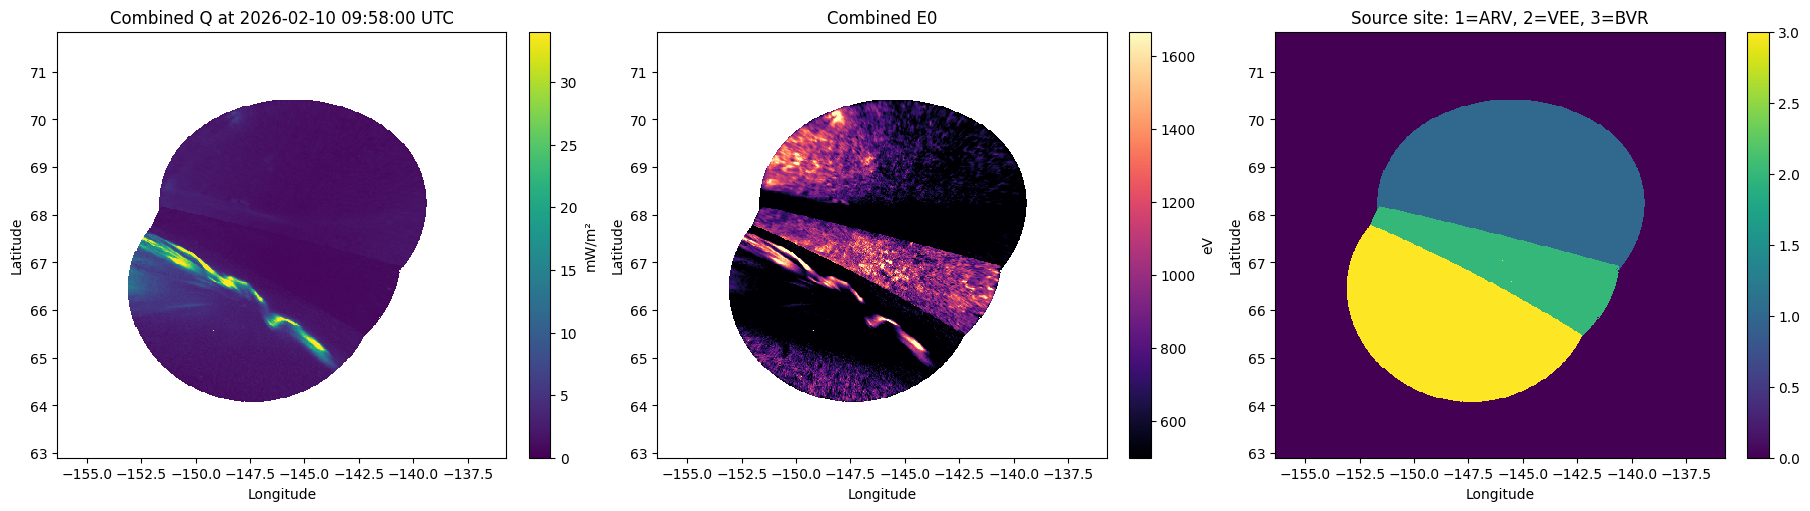

In [ ]:
inspection_time = '09:59:00'
with h5py.File(output_file, 'r') as h5:
    completed_indices = np.flatnonzero(h5['completed'][:])
    if completed_indices.size == 0:
        raise ValueError('The output file contains no completed inversions')
    desired_time = np.datetime64(parse_utc(inspection_time), 'us')
    all_times = np.array(target_times, dtype='datetime64[us]')
    time_index = int(completed_indices[np.argmin(np.abs(all_times[completed_indices] - desired_time))])
    q_image = h5['combined/q_mW_m2'][time_index]
    e0_image = h5['combined/e0_eV'][time_index]
    source_image = h5['combined/source_site'][time_index]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
q_plot = axes[0].pcolormesh(
    decgridlon, decgridlat, q_image, shading='nearest',
    vmin=0, vmax=finite_percentile(q_image),
)
axes[0].set_title(f'Combined Q at {target_times[time_index]} UTC')
fig.colorbar(q_plot, ax=axes[0], label='mW/m²')
e0_plot = axes[1].pcolormesh(
    decgridlon, decgridlat, e0_image, shading='nearest', cmap='magma',
    vmin=500, vmax=finite_percentile(e0_image),
)
axes[1].set_title('Combined E0')
fig.colorbar(e0_plot, ax=axes[1], label='eV')
site_plot = axes[2].pcolormesh(decgridlon, decgridlat, source_image, shading='nearest', vmin=0, vmax=3)
axes[2].set_title('Source site: 1=ARV, 2=VEE, 3=BVR')
fig.colorbar(site_plot, ax=axes[2])
for axis in axes:
    axis.set_xlabel('Longitude')
    axis.set_ylabel('Latitude')
plt.show()